<div style="background:linear-gradient(135deg,#1a1a2e,#0f3460);
              border-radius:16px;padding:40px 30px;text-align:center;
              border:1px solid #e94560;margin-bottom:10px;">
  <h1 style="color:#e94560;font-family:Georgia,serif;font-size:2.4em;margin:0 0 10px 0;">
    ☀️ Solar Power Generation Forecasting System
  </h1>
  <h3 style="color:#a8dadc;font-family:monospace;font-weight:normal;margin:0 0 18px 0;">
    Plant 1 &nbsp;|&nbsp; EDA · Fault Detection · GridSearchCV RF · SARIMA · LSTM
  </h3>
  <div style="color:#ccc;font-size:0.95em;line-height:1.7;">
    <b style="color:#e94560;">Dataset:</b> Kaggle — Solar Power Generation Data &nbsp;|&nbsp;
    <b style="color:#e94560;">Models:</b> Linear Reg · Decision Tree · Random Forest (tuned) · SARIMA · LSTM
  </div>
</div>

## Project Overview

Solar power forecasting is critical for grid stability, energy trading, and maintenance planning.
This notebook delivers a **complete, production-ready pipeline**:

| Step | Content |
|------|---------|
| **Data** | Load, merge, clean Plant 1 generation + weather sensor CSVs |
| **EDA** | Spearman correlation, distributions, pairplot |
| **Fault Detection** | Day-wise profiles, best/worst day, CoV-based severity classification |
| **Weather** | Trend analysis, seasonal decomposition, thermal outlier detection |
| **ML Models** | Linear Regression → Decision Tree → **Random Forest with GridSearchCV** |
| **Feature Importance** | Dedicated RF importance analysis with permutation validation |
| **SARIMA** | Classical time-series model on daily aggregated AC power |
| **LSTM** | Deep learning temporal model with 2-layer architecture |
| **Comparison** | All 5 models side-by-side on MAE · RMSE · R² · MAPE |

> 📌 Place both CSV files in a `data/` folder next to this notebook before running.

<div style="background:#0f3460;border-left:5px solid #e94560;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#e94560;font-size:1.2em;font-weight:bold;">Section 1 — Environment Setup</span>
</div>

In [1]:
# ── Standard library ──────────────────────────────────────────────────────
import os, json, random, logging, warnings
from pathlib import Path
from datetime import datetime

# ── Scientific stack ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scikit-learn ───────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
import joblib

# ── Statsmodels (SARIMA) ───────────────────────────────────────────────────
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm

# ── Suppress noise ─────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

# ── Directories ────────────────────────────────────────────────────────────
DATA_DIR   = Path('data')
OUTPUT_DIR = Path('outputs')
MODEL_DIR  = Path('models')
for d in [DATA_DIR, OUTPUT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Plot palette ───────────────────────────────────────────────────────────
DARK_BG  = '#0d1117'
PANEL_BG = '#161b22'
C1, C2, C3, C4 = '#58a6ff', '#f78166', '#3fb950', '#d2a8ff'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,   'axes.facecolor':  PANEL_BG,
    'axes.edgecolor':   '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color':      '#8b949e', 'ytick.color':     '#8b949e',
    'text.color':       '#c9d1d9', 'grid.color':      '#21262d',
    'grid.linewidth':   0.7,       'font.family':     'monospace',
    'axes.titlesize':   12,        'axes.labelsize':  10,
    'legend.facecolor': PANEL_BG,  'legend.edgecolor':'#30363d',
})
print(f'Pandas     : {pd.__version__}')
print(f'NumPy      : {np.__version__}')
print('Environment ready ✓')

Pandas     : 3.0.3
NumPy      : 1.26.4
Environment ready ✓


In [2]:
import tensorflow as tf

In [3]:
# ── TensorFlow / Keras ─────────────────────────────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

logging.basicConfig(level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s', datefmt='%H:%M:%S')
logger = logging.getLogger(__name__)


print(f'TensorFlow : {tf.__version__}')


TensorFlow : 2.16.1


<div style="background:#1c2833;border-left:5px solid #f78166;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#f78166;font-size:1.1em;font-weight:bold;">
     Plant Selection — Run for Plant 1 or Plant 2
  </span><br>
  <span style="color:#c9d1d9;font-size:0.95em;">
    Set <code>PLANT_ID = 1</code> or <code>PLANT_ID = 2</code> below.
    The entire pipeline (EDA → RF → SARIMA → LSTM) runs identically for both plants.
    To compare both plants, run all cells twice with different PLANT_ID values.
  </span>
</div>

In [4]:
# ══════════════════════════════════════════════════════════════
# PLANT SELECTION — Set PLANT_ID to 1 or 2
# ══════════════════════════════════════════════════════════════
PLANT_ID = 1      

GEN_FILE     = DATA_DIR / f'Plant_{PLANT_ID}_Generation_Data.csv'
WEATHER_FILE = DATA_DIR / f'Plant_{PLANT_ID}_Weather_Sensor_Data.csv'

print(f'Analysing Plant {PLANT_ID}')
print(f'  Generation : {GEN_FILE}')
print(f'  Weather    : {WEATHER_FILE}')

Analysing Plant 1
  Generation : data/Plant_1_Generation_Data.csv
  Weather    : data/Plant_1_Weather_Sensor_Data.csv


<div style="background:#0f3460;border-left:5px solid #e94560;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#e94560;font-size:1.2em;font-weight:bold;">Section 2 — Data Loading, Cleaning & Feature Engineering</span>
</div>

### Merge Strategy
- Generation CSV: **one row per (timestamp × inverter)** — 22 inverters every 15 min  
- Weather CSV: **one row per timestamp** (plant-wide sensor, no SOURCE_KEY)  
- Merge on `DATE_TIME` → each inverter reading gains its weather snapshot

### Engineered Features

| Feature | Formula | Purpose |
|---------|---------|---------|
| `TOTAL_MINUTES_PASSED` | `HOUR×60 + MIN` | Continuous intra-day position (better than discrete HOUR) |
| `DELTA_TEMPERATURE` | `MODULE − AMBIENT` | Heat transfer proxy |
| `DC_AC_RATIO` | `DC/(AC+ε)` | Conversion efficiency indicator |
| `IRRAD_X_MODULE` | `IRRAD × MODULE_TEMP` | Thermal-irradiance interaction |
| `NEW_DAILY_YIELD` | `.diff()` on `DAILY_YIELD` | Energy increment per 15 min |
| Rolling mean/std (3-step) | Per-inverter window | Short-term trend & volatility |
| Lag features (t-1, t-3, t-6) | Shifted `AC_POWER` | Autoregressive signal |

In [5]:
def load_and_merge(gen_path: Path, weather_path: Path) -> pd.DataFrame:
    logger.info('Loading generation data ...')
    gen = pd.read_csv(gen_path)
    gen['DATE_TIME'] = pd.to_datetime(gen['DATE_TIME'], dayfirst=True)
    gen = gen.drop(columns=[c for c in ['PLANT_ID'] if c in gen.columns])

    logger.info('Loading weather sensor data ...')
    weather = pd.read_csv(weather_path)
    weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])
    weather = weather.drop(columns=[c for c in ['PLANT_ID','SOURCE_KEY'] if c in weather.columns])
    weather = weather.drop_duplicates(subset=['DATE_TIME'])

    df = pd.merge(gen, weather, on='DATE_TIME', how='inner')
    logger.info(f'Merged shape: {df.shape}')
    return df


def clean(df: pd.DataFrame) -> pd.DataFrame:
    n0 = len(df)
    keys = ['DATE_TIME','SOURCE_KEY'] if 'SOURCE_KEY' in df.columns else ['DATE_TIME']
    df = df.drop_duplicates(subset=keys)
    df = df[(df['AC_POWER'] >= 0) & (df['DC_POWER'] >= 0)]
    critical = ['AC_POWER','DC_POWER','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']
    df = df.dropna(subset=[c for c in critical if c in df.columns]).reset_index(drop=True)
    logger.info(f'Cleaned: {n0} → {len(df)} rows  ({n0-len(df)} removed)')
    return df


# LEAKAGE-FREE FEATURE ENGINEERING
# Features explicitly EXCLUDED:
#   DC_POWER       — Spearman ρ=0.99 with AC_POWER; including it gives a surrogate
#                    target and inflates R² to ~100%
#   DC_AC_RATIO    — DC/(AC+ε): uses both DC_POWER and AC_POWER (the target)
#   DAILY_YIELD    — cumulative within-day energy counter: encodes same-day
#                    future readings → look-ahead bias

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    logger.info('Engineering features (leakage-free) ...')

    df['DATE']                = df['DATE_TIME'].dt.date
    df['TIME']                = df['DATE_TIME'].dt.time.astype(str)
    df['HOUR']                = df['DATE_TIME'].dt.hour
    df['MINUTES']             = df['DATE_TIME'].dt.minute
    df['TOTAL_MINUTES_PASSED']= df['HOUR'] * 60 + df['MINUTES']
    df['DAY']                 = df['DATE_TIME'].dt.day
    df['MONTH']               = df['DATE_TIME'].dt.month
    df['WEEK']                = df['DATE_TIME'].dt.isocalendar().week.astype(int)
    df['DATE_STR']            = df['DATE_TIME'].dt.date.astype(str)

    # Domain features — SAFE: no AC_POWER in any formula
    df['DELTA_TEMPERATURE'] = df['MODULE_TEMPERATURE'] - df['AMBIENT_TEMPERATURE']
    df['IRRAD_X_MODULE']    = df['IRRADIATION'] * df['MODULE_TEMPERATURE']

    if 'SOURCE_KEY' in df.columns:
        df['SOURCE_KEY_NUM'] = LabelEncoder().fit_transform(df['SOURCE_KEY'])
    else:
        df['SOURCE_KEY_NUM'] = 0

    grp = 'SOURCE_KEY' if 'SOURCE_KEY' in df.columns else None
    df  = df.sort_values(([grp,'DATE_TIME'] if grp else ['DATE_TIME'])).reset_index(drop=True)

    # Daily yield increment — computed for SARIMA series building only
    # NOT included in ML feature sets
    if 'DAILY_YIELD' in df.columns:
        if grp:
            df['NEW_DAILY_YIELD'] = (df.groupby(grp)['DAILY_YIELD'].diff()
                                       .fillna(0).clip(lower=0))
        else:
            df['NEW_DAILY_YIELD'] = df['DAILY_YIELD'].diff().fillna(0).clip(lower=0)

    # Rolling stats — SHIFTED by 1 step to exclude current-row value
    # WITHOUT shift: rolling(3).mean() at row i = mean(AC[i], AC[i-1], AC[i-2])
    #   which INCLUDES the target AC[i] → leakage
    # WITH shift(1): mean(AC[i-1], AC[i-2], AC[i-3]) → strictly past, safe
    for col in ['AC_POWER', 'IRRADIATION', 'MODULE_TEMPERATURE']:
        if grp:
            df[f'{col}_ROLL3_MEAN'] = df.groupby(grp)[col].transform(
                lambda s: s.shift(1).rolling(3, min_periods=1).mean().fillna(0)
            )
            df[f'{col}_ROLL3_STD'] = df.groupby(grp)[col].transform(
                lambda s: s.shift(1).rolling(3, min_periods=1).std().fillna(0)
            )
        else:
            df[f'{col}_ROLL3_MEAN'] = (
                df[col].shift(1).rolling(3, min_periods=1).mean().fillna(0)
            )
            df[f'{col}_ROLL3_STD'] = (
                df[col].shift(1).rolling(3, min_periods=1).std().fillna(0)
            )
    # Lag features — shift(n) is strictly past values, safe
    for lag in [1, 3, 6]:
        if grp:
            df[f'AC_POWER_LAG{lag}'] = (df.groupby(grp)['AC_POWER']
                                           .shift(lag).fillna(0))
        else:
            df[f'AC_POWER_LAG{lag}'] = df['AC_POWER'].shift(lag).fillna(0)

    df = df.dropna().reset_index(drop=True)
    logger.info(f'Feature engineering done — {len(df.columns)} cols, {len(df)} rows')
    return df


# ── Run ────────────────────────────────────────────────────────────────────
df_raw = load_and_merge(GEN_FILE, WEATHER_FILE)
df_raw = clean(df_raw)
df     = engineer_features(df_raw.copy())

print(f'\n Shape            : {df.shape}')
print(f' Date range       : {df["DATE_TIME"].min()}  →  {df["DATE_TIME"].max()}')
print(f' Unique inverters : {df["SOURCE_KEY"].nunique() if "SOURCE_KEY" in df.columns else 1}')
print(f' Unique dates     : {df["DATE"].nunique()}')
print(f' Null values      : {df.isnull().sum().sum()}')
df.head()

02:21:35 | INFO | Loading generation data ...
02:21:35 | INFO | Loading weather sensor data ...
02:21:35 | INFO | Merged shape: (68774, 9)
02:21:35 | INFO | Cleaned: 68774 → 68774 rows  (0 removed)
02:21:35 | INFO | Engineering features (leakage-free) ...
02:21:35 | INFO | Feature engineering done — 31 cols, 68774 rows



 Shape            : (68774, 31)
 Date range       : 2020-05-15 00:00:00  →  2020-06-17 23:45:00
 Unique inverters : 22
 Unique dates     : 34
 Null values      : 0


,DATE_TIME,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DATE,TIME,HOUR,MINUTES,TOTAL_MINUTES_PASSED,DAY,MONTH,WEEK,DATE_STR,DELTA_TEMPERATURE,IRRAD_X_MODULE,SOURCE_KEY_NUM,NEW_DAILY_YIELD,AC_POWER_ROLL3_MEAN,AC_POWER_ROLL3_STD,IRRADIATION_ROLL3_MEAN,IRRADIATION_ROLL3_STD,MODULE_TEMPERATURE_ROLL3_MEAN,MODULE_TEMPERATURE_ROLL3_STD,AC_POWER_LAG1,AC_POWER_LAG3,AC_POWER_LAG6
0,2020-05-15 00:00:00,1BY6WEcLGh8j5v7,0.000,0.000,0.000,6259559.000,25.184,22.858,0.000,2020-05-15,00:00:00,0,0,0,15,5,20,2020-05-15,-2.327,0.000,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,2020-05-15 00:15:00,1BY6WEcLGh8j5v7,0.000,0.000,0.000,6259559.000,25.085,22.762,0.000,2020-05-15,00:15:00,0,15,15,15,5,20,2020-05-15,-2.323,0.000,0,0.000,0.000,0.000,0.000,0.000,22.858,0.000,0.000,0.000,0.000
2,2020-05-15 00:30:00,1BY6WEcLGh8j5v7,0.000,0.000,0.000,6259559.000,24.936,22.592,0.000,2020-05-15,00:30:00,0,30,30,15,5,20,2020-05-15,-2.343,0.000,0,0.000,0.000,0.000,0.000,0.000,22.810,0.068,0.000,0.000,0.000
3,2020-05-15 00:45:00,1BY6WEcLGh8j5v7,0.000,0.000,0.000,6259559.000,24.846,22.361,0.000,2020-05-15,00:45:00,0,45,45,15,5,20,2020-05-15,-2.485,0.000,0,0.000,0.000,0.000,0.000,0.000,22.737,0.134,0.000,0.000,0.000
4,2020-05-15 01:00:00,1BY6WEcLGh8j5v7,0.000,0.000,0.000,6259559.000,24.622,22.165,0.000,2020-05-15,01:00:00,1,0,60,15,5,20,2020-05-15,-2.456,0.000,0,0.000,0.000,0.000,0.000,0.000,22.572,0.201,0.000,0.000,0.000


In [6]:
key_cols = ['DC_POWER','AC_POWER','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE',
            'IRRADIATION','DELTA_TEMPERATURE','NEW_DAILY_YIELD']
key_cols = [c for c in key_cols if c in df.columns]
df[key_cols].describe().round(3).style.background_gradient(cmap='YlOrRd')

,DC_POWER,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DELTA_TEMPERATURE,NEW_DAILY_YIELD
count,68774.000000,68774.000000,68774.000000,68774.000000,68774.000000,68774.000000,68774.000000
mean,3147.177000,307.778000,25.559000,31.245000,0.232000,5.686000,78.238000
std,4036.442000,394.395000,3.361000,12.308000,0.302000,9.592000,113.865000
min,0.000000,0.000000,20.399000,18.140000,0.000000,-3.416000,0.000000
25%,0.000000,0.000000,22.724000,21.124000,0.000000,-1.769000,0.000000
50%,428.571000,41.450000,24.670000,24.819000,0.032000,-0.505000,10.732000
75%,6365.469000,623.561000,27.960000,41.694000,0.455000,13.333000,156.420000
max,14471.125000,1410.950000,35.252000,65.546000,1.222000,35.243000,3187.833000


<div style="background:#0f3460;border-left:5px solid #e94560;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#e94560;font-size:1.2em;font-weight:bold;">Section 3 — EDA: Correlation & Distributions</span>
</div>

**Spearman rank correlation** (non-parametric) is used instead of Pearson — solar relationships  
are non-linear above irradiation thresholds, so Pearson would underestimate true dependencies.

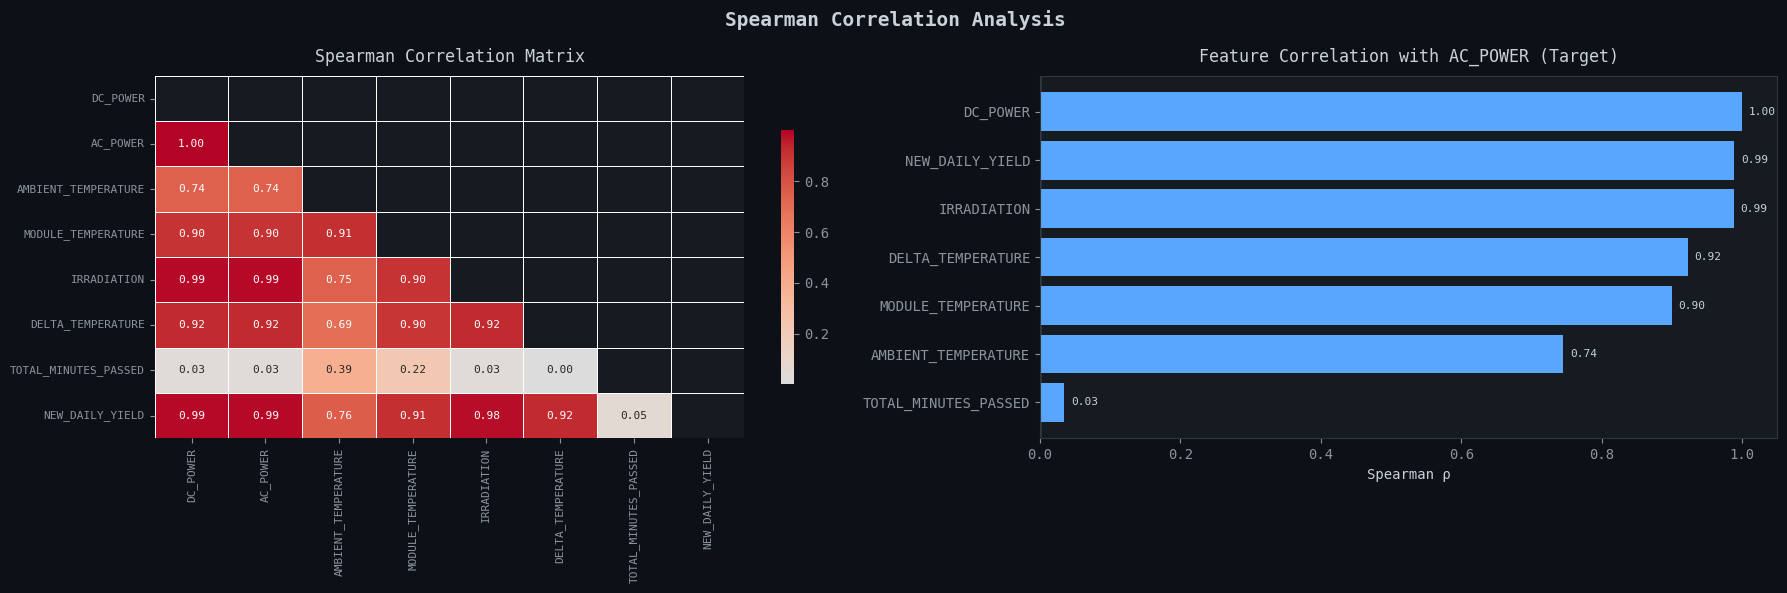

In [7]:
# ── Spearman correlation heatmap + target bar ──────────────────────────────
corr_cols = ['DC_POWER','AC_POWER','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE',
             'IRRADIATION','DELTA_TEMPERATURE','DC_AC_RATIO',
             'TOTAL_MINUTES_PASSED','NEW_DAILY_YIELD']
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18,6))
fig.suptitle('Spearman Correlation Analysis', fontsize=14, color='#c9d1d9', fontweight='bold')

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0], cmap='coolwarm', center=0, annot=True,
            fmt='.2f', linewidths=0.4, annot_kws={'size':8}, cbar_kws={'shrink':0.7})
axes[0].set_title('Spearman Correlation Matrix', pad=10); axes[0].tick_params(labelsize=8)

target_corr = corr['AC_POWER'].drop('AC_POWER').sort_values()
colors = [C2 if v < 0 else C1 for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='none')
axes[1].axvline(0, color='#8b949e', lw=1)
axes[1].set_title('Feature Correlation with AC_POWER (Target)', pad=10)
axes[1].set_xlabel('Spearman ρ')
for i, v in enumerate(target_corr.values):
    axes[1].text(v + 0.01*np.sign(v), i, f'{v:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'01_correlation.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

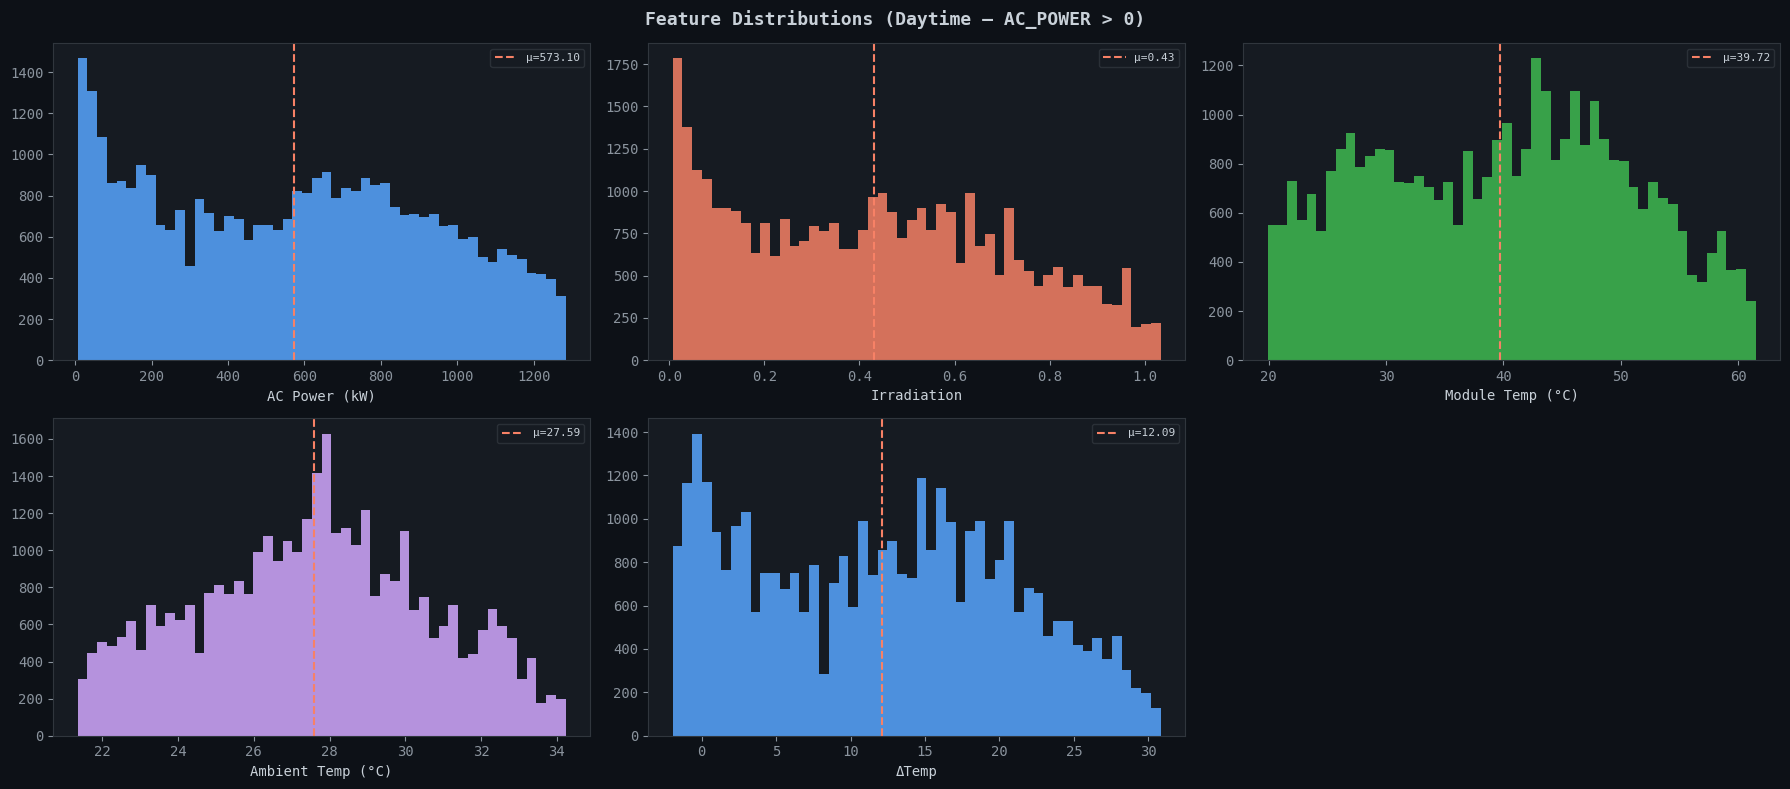

In [8]:
# ── Distribution panels (daytime only) ────────────────────────────────────
day_df = df[df['AC_POWER'] > 0].copy()
fig, axes = plt.subplots(2, 3, figsize=(18,8))
fig.suptitle('Feature Distributions (Daytime — AC_POWER > 0)', fontsize=13,
             color='#c9d1d9', fontweight='bold')
specs = [('AC_POWER',C1,'AC Power (kW)'), ('IRRADIATION',C2,'Irradiation'),
         ('MODULE_TEMPERATURE',C3,'Module Temp (°C)'), ('AMBIENT_TEMPERATURE',C4,'Ambient Temp (°C)'),
         ('DELTA_TEMPERATURE',C1,'ΔTemp')]
for ax, (col, color, xlabel) in zip(axes.flat, specs):
    if col not in day_df.columns: continue
    vals = day_df[col]; vals = vals[vals.between(*np.percentile(vals,[1,99]))]
    ax.hist(vals, bins=50, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(vals.mean(), color=C2, lw=1.5, ls='--', label=f'μ={vals.mean():.2f}')
    ax.set_xlabel(xlabel); ax.legend(fontsize=8)
# remove the unused subplot(s)
for i in range(len(specs), len(axes.flat)):
    fig.delaxes(axes.flat[i])
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'02_distributions.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

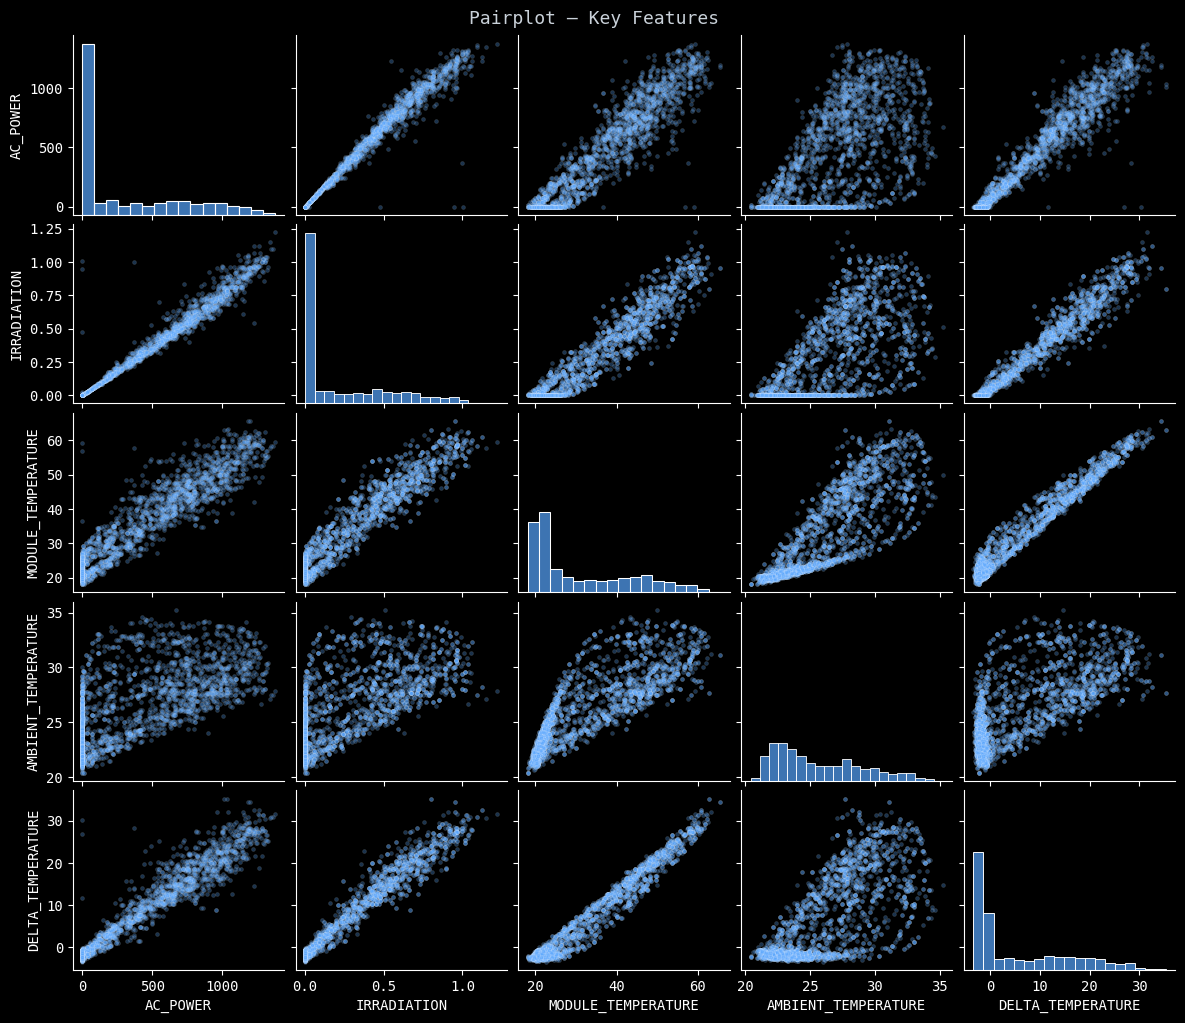

In [9]:
# ── Pairplot (sampled) ─────────────────────────────────────────────────────
pair_cols = ['AC_POWER','IRRADIATION','MODULE_TEMPERATURE','AMBIENT_TEMPERATURE','DELTA_TEMPERATURE']
pair_cols = [c for c in pair_cols if c in df.columns]
with plt.style.context('dark_background'):
    g = sns.pairplot(df[pair_cols].sample(min(3000,len(df)), random_state=SEED),
                     plot_kws={'alpha':0.3,'s':8,'color':C1}, diag_kws={'color':C1,'alpha':0.7})
    g.fig.suptitle('Pairplot — Key Features', y=1.01, fontsize=13, color='#c9d1d9')
    g.fig.set_size_inches(12, 10)
    plt.savefig(OUTPUT_DIR/'03_pairplot.png', dpi=120, bbox_inches='tight')
    plt.show()

<div style="background:#0f3460;border-left:5px solid #e94560;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#e94560;font-size:1.2em;font-weight:bold;">Section 4 — Day-wise Analysis & Fault / Abnormality Detection</span>
</div>

An ideal solar day produces a smooth **bell curve** peaking at solar noon.  
Deviations indicate:  Cloud cover &nbsp;|&nbsp; Inverter faults &nbsp;|&nbsp; Heavy overcast

**Fault severity** is quantified using **Coefficient of Variation (CoV = σ/μ)** during daytime hours:

| CoV Range | Classification |
|-----------|---------------|
| > 0.70 | 🔴 Very High Fluctuation |
| 0.40 – 0.70 | 🟡 High Fluctuation |
| 0.20 – 0.40 | 🟢 Low Fluctuation |
| < 0.20 | ✅ Very Stable |

In [10]:
# ── Plant-level aggregation (sum all inverters per timestamp) ──────────────
agg_cols = {c:'sum' for c in ['DC_POWER','AC_POWER'] if c in df.columns}
agg_cols.update({c:'mean' for c in ['IRRADIATION','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE']
                 if c in df.columns})
df_plant = df.groupby(['DATE_TIME','DATE_STR','TIME']).agg(agg_cols).reset_index()
df_plant = df_plant.sort_values('DATE_TIME').reset_index(drop=True)
print(f'Plant-level shape: {df_plant.shape}')

Plant-level shape: (3157, 8)


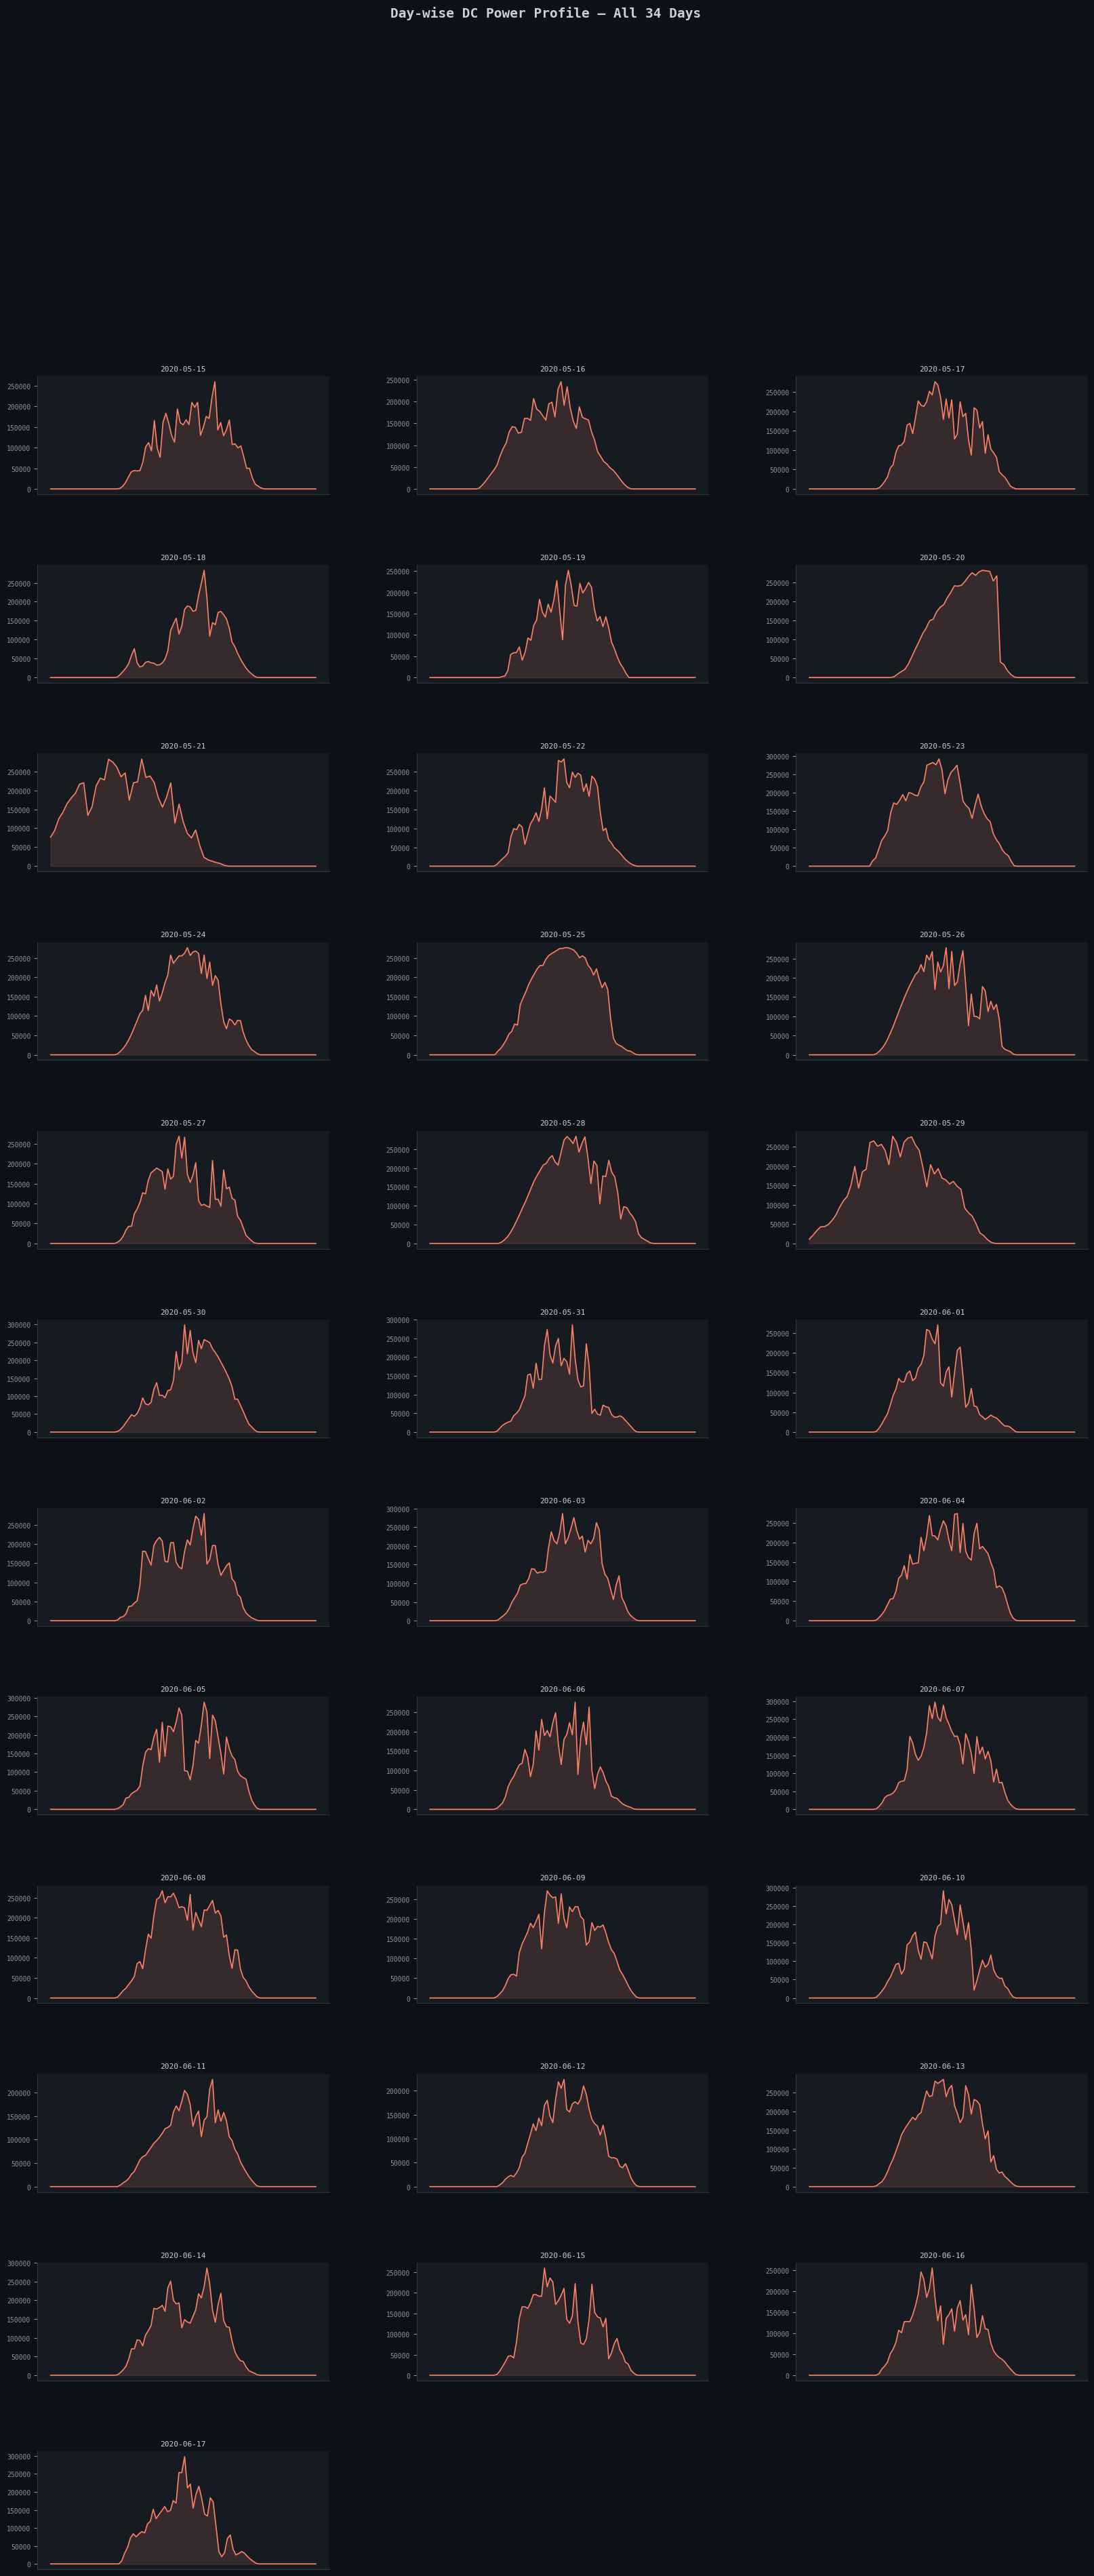

In [11]:
# ── Day-wise DC_POWER multi-plot ──────────────────────────────────────────
def daywise_multiplot(df_p, col='DC_POWER', color=C2, title_pfx='DC Power', save_path=None):
    pivot  = df_p.pivot_table(values=col, index='TIME', columns='DATE_STR')
    dates  = sorted(pivot.columns)
    n_cols = 3; n_rows = int(np.ceil(len(dates)/n_cols))
    fig = plt.figure(figsize=(20, n_rows*3.5)); fig.patch.set_facecolor(DARK_BG)
    fig.suptitle(f'Day-wise {title_pfx} Profile — All {len(dates)} Days',
                 fontsize=14, color='#c9d1d9', fontweight='bold', y=1.01)
    fig.subplots_adjust(wspace=0.3, hspace=0.6)
    for i, date in enumerate(dates, 1):
        ax = fig.add_subplot(n_rows, n_cols, i); ax.set_facecolor(PANEL_BG)
        s = pivot[date].dropna()
        ax.plot(range(len(s)), s.values, color=color, lw=1.2)
        ax.fill_between(range(len(s)), s.values, alpha=0.15, color=color)
        ax.set_title(date, color='#c9d1d9', fontsize=8); ax.set_xticks([])
        ax.tick_params(labelsize=7, colors='#8b949e')
        for spine in ax.spines.values(): spine.set_color('#30363d')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if save_path: plt.savefig(save_path, dpi=120, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()

daywise_multiplot(df_plant, save_path=OUTPUT_DIR/'04_daywise_dc_power.png')

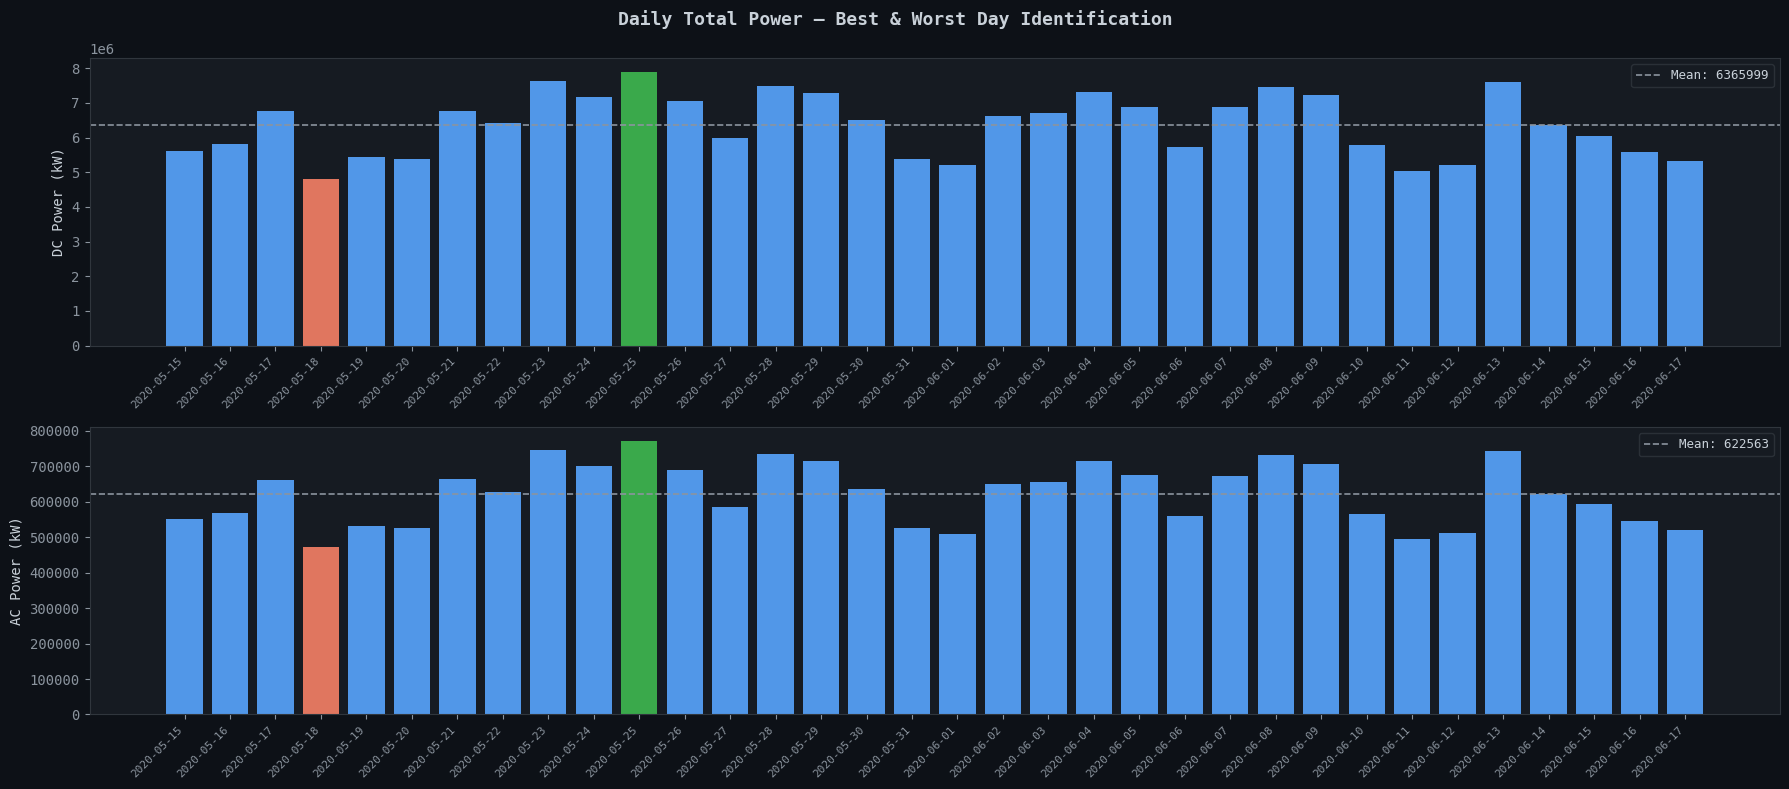

Best day  : 2020-05-25  (7,898,965 kW)
Worst day : 2020-05-18  (4,812,549 kW)


In [12]:
# ── Daily totals + best/worst identification ───────────────────────────────
daily_dc  = df_plant.groupby('DATE_STR')['DC_POWER'].sum()
daily_ac  = df_plant.groupby('DATE_STR')['AC_POWER'].sum()
best_day  = daily_dc.idxmax(); worst_day = daily_dc.idxmin()

fig, axes = plt.subplots(2, 1, figsize=(18,8))
fig.suptitle('Daily Total Power — Best & Worst Day Identification', fontsize=13,
             color='#c9d1d9', fontweight='bold')
for ax, (series, ylabel) in zip(axes, [(daily_dc.sort_index(),'DC Power (kW)'),
                                        (daily_ac.sort_index(),'AC Power (kW)')]):
    ax.bar(range(len(series)), series.values,
           color=[C3 if d==best_day else C2 if d==worst_day else C1 for d in series.index],
           edgecolor='none', alpha=0.9)
    ax.set_xticks(range(len(series))); ax.set_xticklabels(series.index, rotation=45, ha='right', fontsize=8)
    ax.axhline(series.mean(), color='#8b949e', lw=1.2, ls='--', label=f'Mean: {series.mean():.0f}')
    ax.set_ylabel(ylabel); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'05_daily_totals.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Best day  : {best_day}  ({daily_dc[best_day]:,.0f} kW)')
print(f'Worst day : {worst_day}  ({daily_dc[worst_day]:,.0f} kW)')

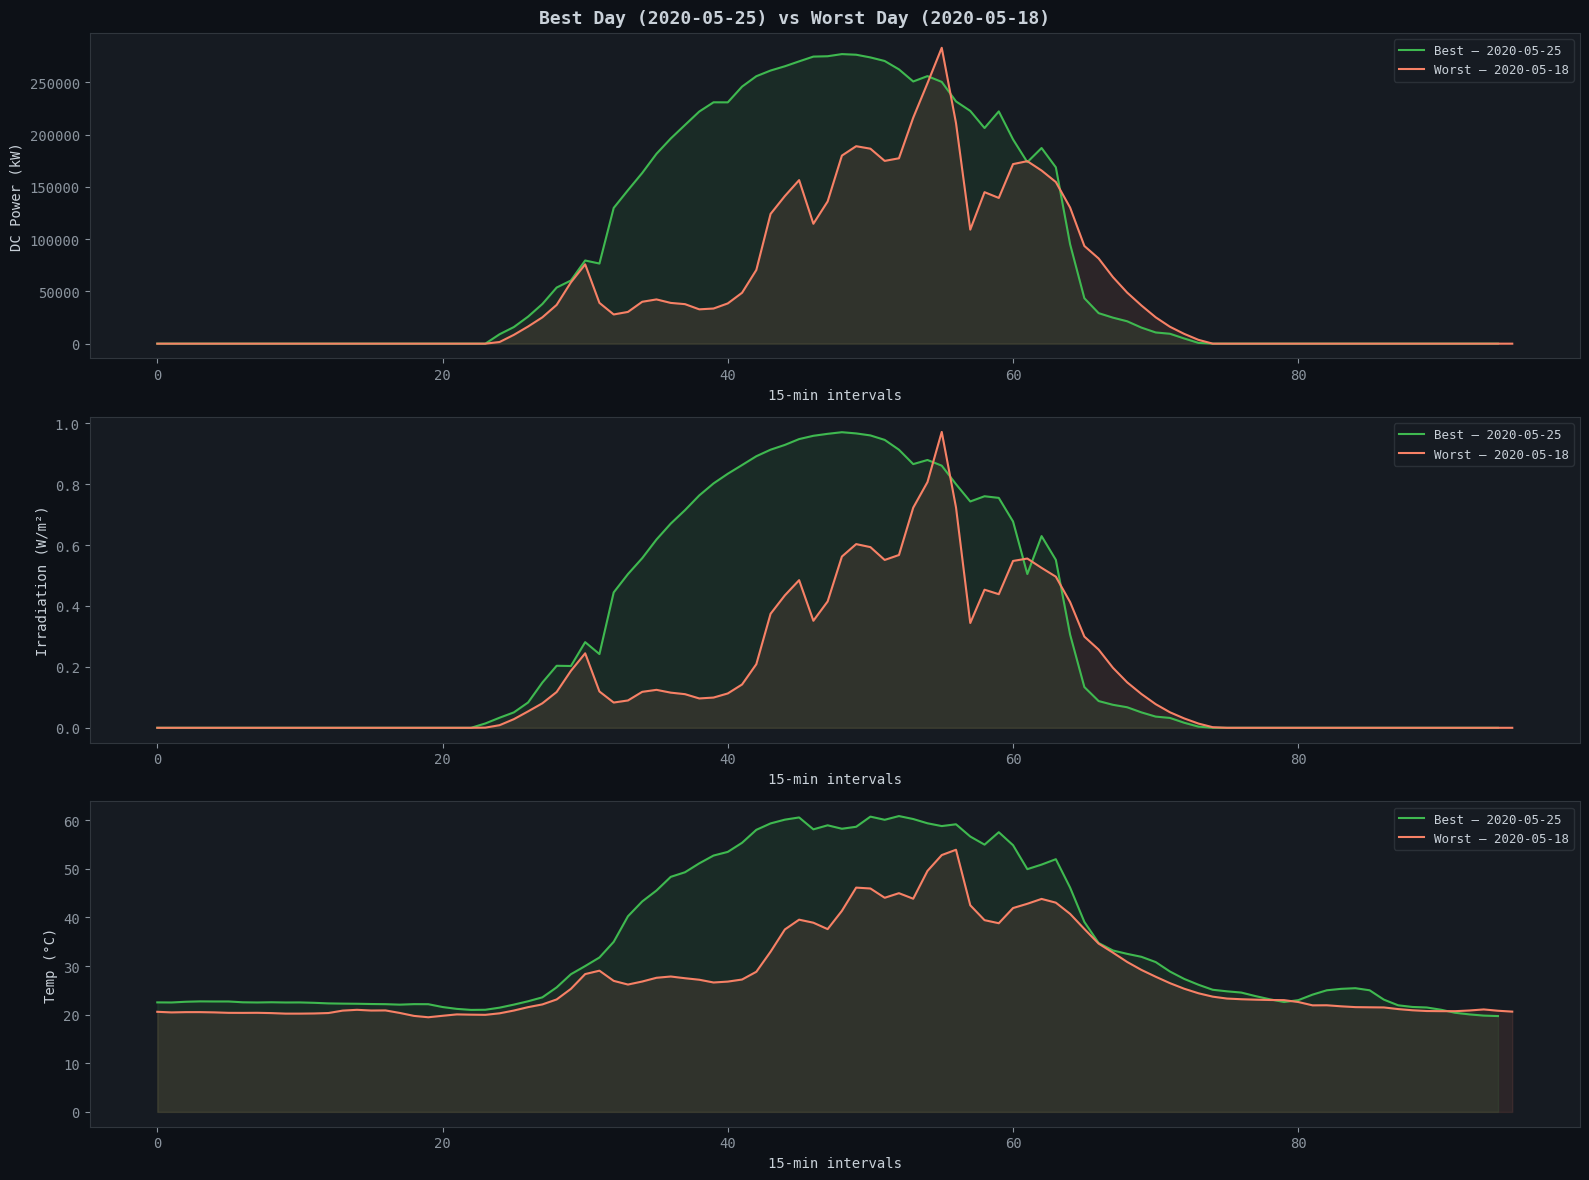

In [13]:
# ── Best vs Worst day side-by-side ────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16,12))
fig.suptitle(f'Best Day ({best_day}) vs Worst Day ({worst_day})',
             fontsize=13, color='#c9d1d9', fontweight='bold')

plot_pairs = [('DC_POWER','DC Power (kW)'), ('IRRADIATION','Irradiation (W/m²)'),
              ('MODULE_TEMPERATURE','Temp (°C)')]

for (col, ylabel), ax in zip(plot_pairs, axes):
    if col not in df_plant.columns: continue
    for date, color, label in [(best_day, C3,'Best'), (worst_day, C2,'Worst')]:
        d = df_plant[df_plant['DATE_STR']==date].sort_values('TIME').reset_index(drop=True)
        ax.plot(d.index, d[col].values, color=color, lw=1.5, label=f'{label} — {date}')
        ax.fill_between(d.index, d[col].values, alpha=0.1, color=color)
    ax.set_ylabel(ylabel); ax.legend(fontsize=9); ax.set_xlabel('15-min intervals')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'06_best_vs_worst.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

In [14]:
# ── Fault severity classification (CoV-based) ─────────────────────────────
pivot_dc = df_plant.pivot_table(values='DC_POWER', index='TIME', columns='DATE_STR')
daytime  = pivot_dc[pivot_dc.sum(axis=1) > 0]
cv       = (daytime.std() / (daytime.mean() + 1e-6)).sort_values(ascending=False)

def classify(v):
    if v > 0.70: return '🔴 Very High Fluctuation'
    elif v > 0.40: return '🟡 High Fluctuation'
    elif v > 0.20: return '🟢 Low Fluctuation'
    else:          return '✅ Very Stable'

cv_df = pd.DataFrame({'CoV': cv.values, 'Classification': cv.apply(classify)}, index=cv.index)
print('\n── Fault / Fluctuation Severity Classification ──────────────────────────')
print(f'  {"Date":<14}  {"CoV":>7}  Classification')
print('  ' + '─'*52)
for date, row in cv_df.iterrows():
    print(f'  {date:<14}  {row["CoV"]:>7.4f}  {row["Classification"]}')
print()
print(cv_df['Classification'].value_counts().to_string())


── Fault / Fluctuation Severity Classification ──────────────────────────
  Date                CoV  Classification
  ────────────────────────────────────────────────────
  2020-05-18       0.7827  🔴 Very High Fluctuation
  2020-05-31       0.7702  🔴 Very High Fluctuation
  2020-06-01       0.7476  🔴 Very High Fluctuation
  2020-06-06       0.7211  🔴 Very High Fluctuation
  2020-06-17       0.7078  🔴 Very High Fluctuation
  2020-05-22       0.6961  🟡 High Fluctuation
  2020-05-20       0.6863  🟡 High Fluctuation
  2020-06-10       0.6842  🟡 High Fluctuation
  2020-05-30       0.6744  🟡 High Fluctuation
  2020-05-19       0.6738  🟡 High Fluctuation
  2020-06-12       0.6683  🟡 High Fluctuation
  2020-05-25       0.6613  🟡 High Fluctuation
  2020-06-11       0.6419  🟡 High Fluctuation
  2020-05-24       0.6380  🟡 High Fluctuation
  2020-06-03       0.6373  🟡 High Fluctuation
  2020-06-07       0.6366  🟡 High Fluctuation
  2020-05-17       0.6327  🟡 High Fluctuation
  2020-06-13       0.

<div style="background:#0f3460;border-left:5px solid #e94560;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#e94560;font-size:1.2em;font-weight:bold;">Section 5 — Weather Analysis & Seasonal Decomposition</span>
</div>

Seasonal decomposition separates a time series into:  
**Observed = Trend + Seasonality + Residual**  
We use `period=7` (weekly cycle) on daily means — the primary cycle in a 34-day window.

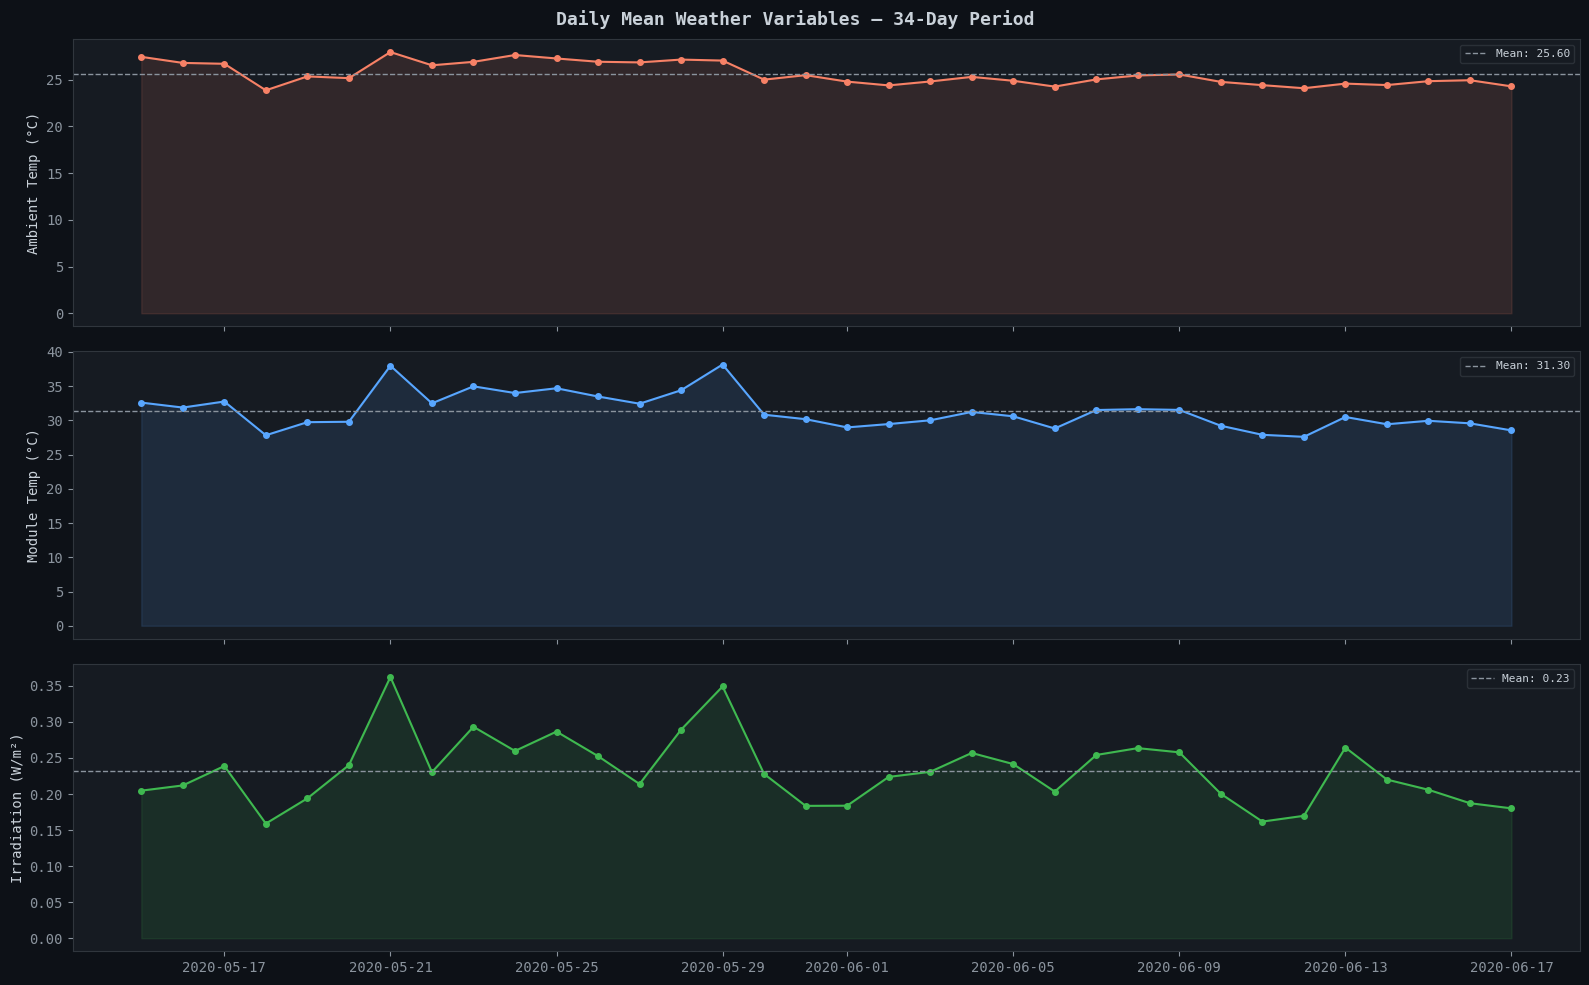

In [15]:
# ── Daily mean weather + dual-axis power/temperature chart ────────────────
daily_w = df_plant.groupby('DATE_STR')[
    ['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION','DC_POWER']].mean()
daily_w.index = pd.to_datetime(daily_w.index)
daily_w = daily_w.sort_index()

fig, axes = plt.subplots(3, 1, figsize=(16,10), sharex=True)
fig.suptitle('Daily Mean Weather Variables — 34-Day Period', fontsize=13,
             color='#c9d1d9', fontweight='bold')
for ax, col, color, ylabel in zip(axes,
        ['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION'],
        [C2, C1, C3],
        ['Ambient Temp (°C)','Module Temp (°C)','Irradiation (W/m²)']):
    if col not in daily_w.columns: continue
    ax.plot(daily_w.index, daily_w[col], color=color, lw=1.5, marker='o', ms=4)
    ax.fill_between(daily_w.index, daily_w[col], alpha=0.12, color=color)
    ax.axhline(daily_w[col].mean(), color='#8b949e', lw=1, ls='--',
               label=f'Mean: {daily_w[col].mean():.2f}')
    ax.set_ylabel(ylabel); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'07_weather_trends.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

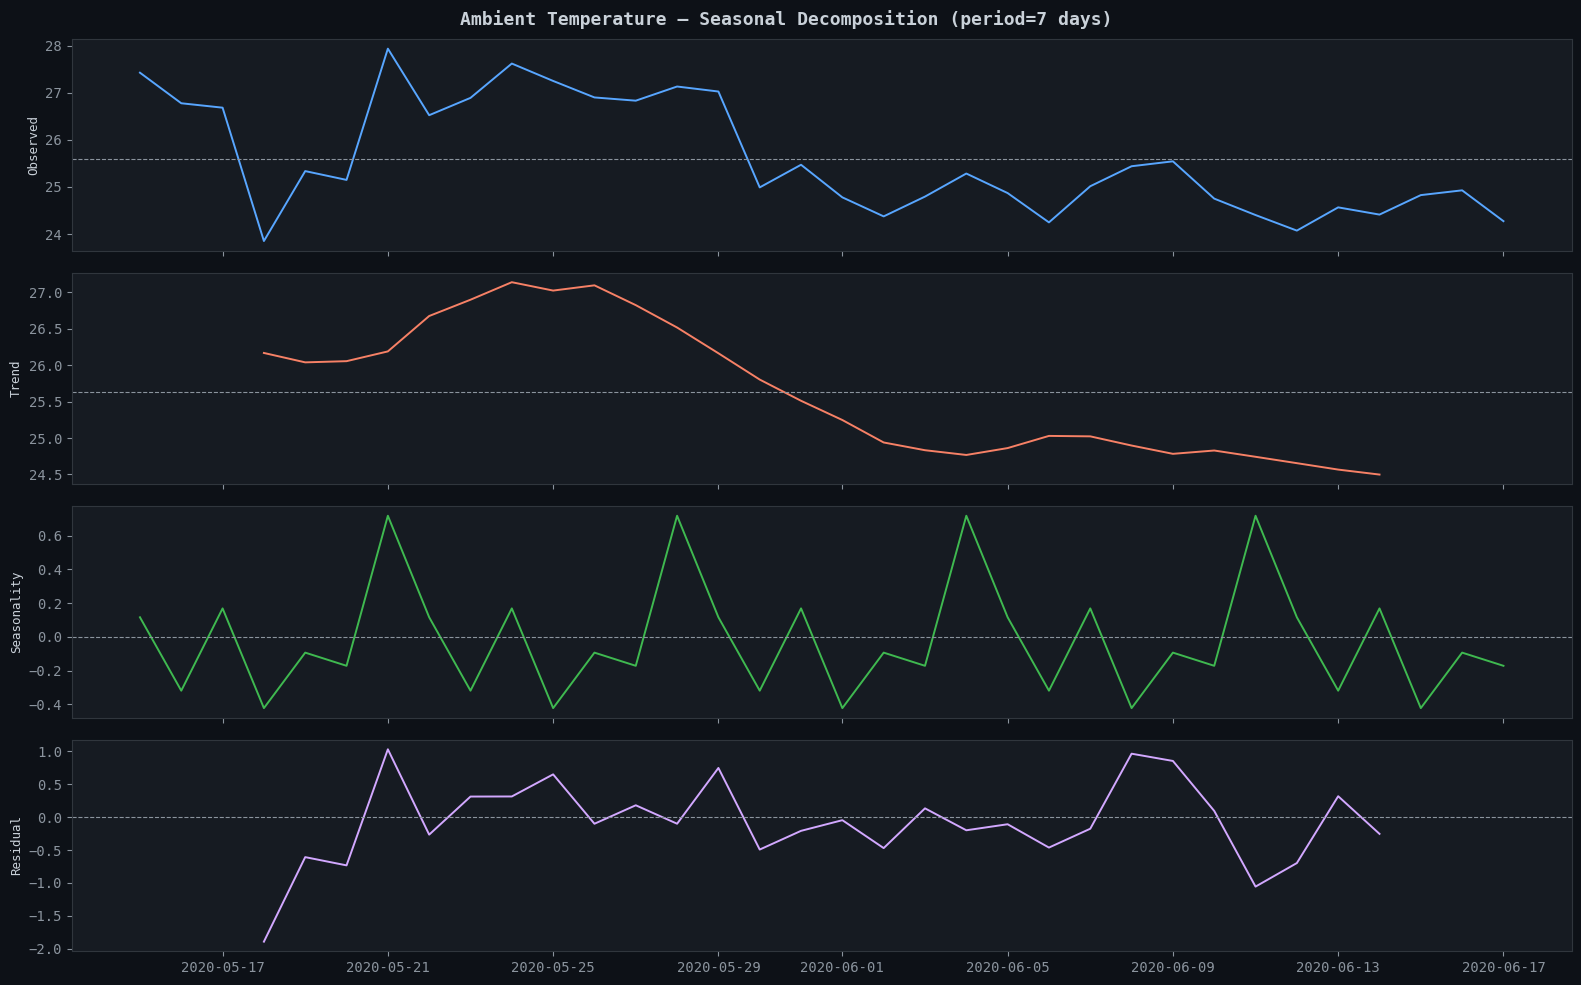

Decomposition complete ✓


In [16]:
# ── Seasonal decomposition — Ambient Temperature ─────────────────────────
try:
    decomp = sm.tsa.seasonal_decompose(
        daily_w['AMBIENT_TEMPERATURE'].dropna(), model='additive', period=7)

    fig, axes = plt.subplots(4, 1, figsize=(16,10), sharex=True)
    fig.suptitle('Ambient Temperature — Seasonal Decomposition (period=7 days)',
                 fontsize=13, color='#c9d1d9', fontweight='bold')
    for ax, (label, series, color) in zip(axes, [
            ('Observed',   decomp.observed, C1), ('Trend',   decomp.trend,    C2),
            ('Seasonality',decomp.seasonal, C3), ('Residual',decomp.resid,    C4)]):
        ax.plot(series.index, series.values, color=color, lw=1.4)
        ax.set_ylabel(label, fontsize=9)
        ref = 0 if label in ['Seasonality','Residual'] else float(series.dropna().mean())
        ax.axhline(ref, color='#8b949e', lw=0.8, ls='--')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'08_seasonal_decomp.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    print('Decomposition complete ✓')
except Exception as e:
    print(f'Skipped: {e}')

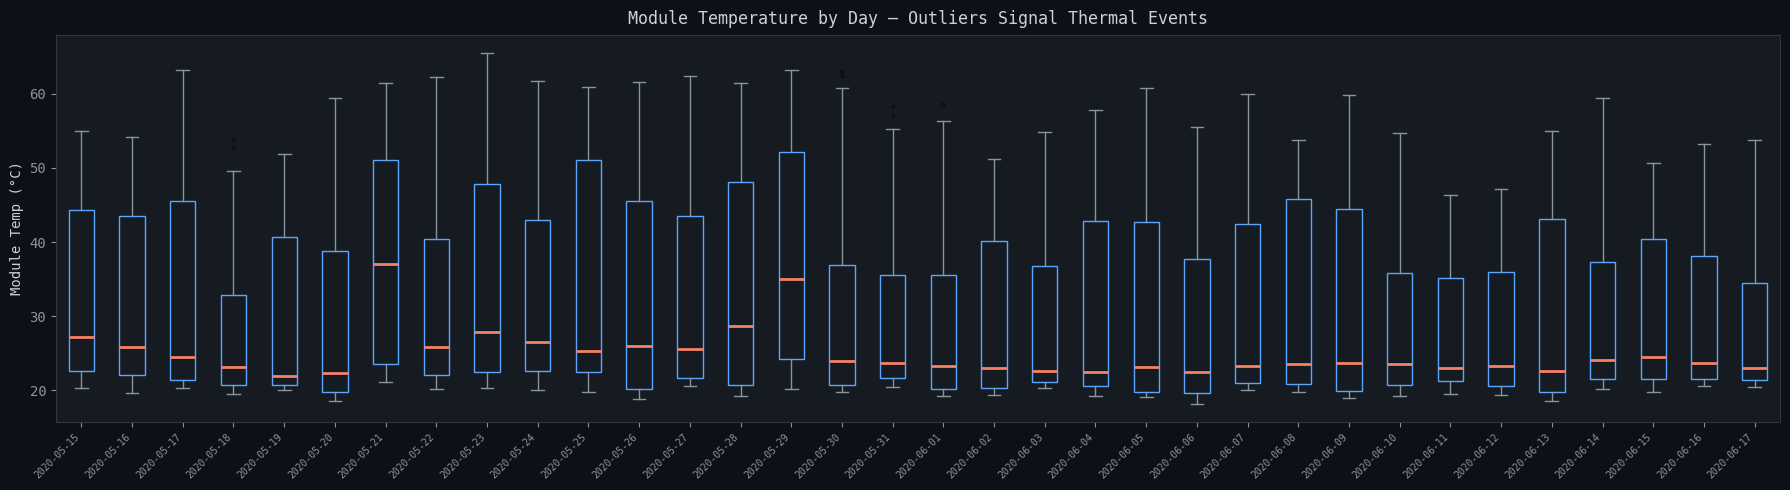

In [17]:
# ── Module temperature outlier boxplot by day ─────────────────────────────
if 'MODULE_TEMPERATURE' in df_plant.columns:
    pivot_mt   = df_plant.pivot_table(values='MODULE_TEMPERATURE', index='TIME', columns='DATE_STR')
    dates_list = sorted(pivot_mt.columns)
    bp_data    = [pivot_mt[d].dropna().values for d in dates_list]

    fig, ax = plt.subplots(figsize=(18,5))
    bp = ax.boxplot(bp_data, patch_artist=True, notch=False,
                    medianprops=dict(color=C2,lw=2), whiskerprops=dict(color='#8b949e'),
                    capprops=dict(color='#8b949e'),
                    flierprops=dict(marker='.',color=C4,ms=4,alpha=0.5))
    for patch in bp['boxes']:
        patch.set_facecolor(PANEL_BG); patch.set_edgecolor(C1)
    ax.set_xticklabels(dates_list, rotation=45, ha='right', fontsize=7)
    ax.set_title('Module Temperature by Day — Outliers Signal Thermal Events', pad=8)
    ax.set_ylabel('Module Temp (°C)')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'09_module_temp_boxes.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()

<div style="background:#0f3460;border-left:5px solid #e94560;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#e94560;font-size:1.2em;font-weight:bold;">Section 6 — Inverter Efficiency Analysis</span>
</div>

High-quality inverters achieve **90–95% efficiency** (AC out / DC in).  
Efficiency drops at low load (<15% capacity) — typical at dawn and dusk.  
`DELTA_TEMPERATURE` confirms the physics: heat transfer between module and air drives output variability.

Overall Plant Efficiency (AC/DC): 9.780%


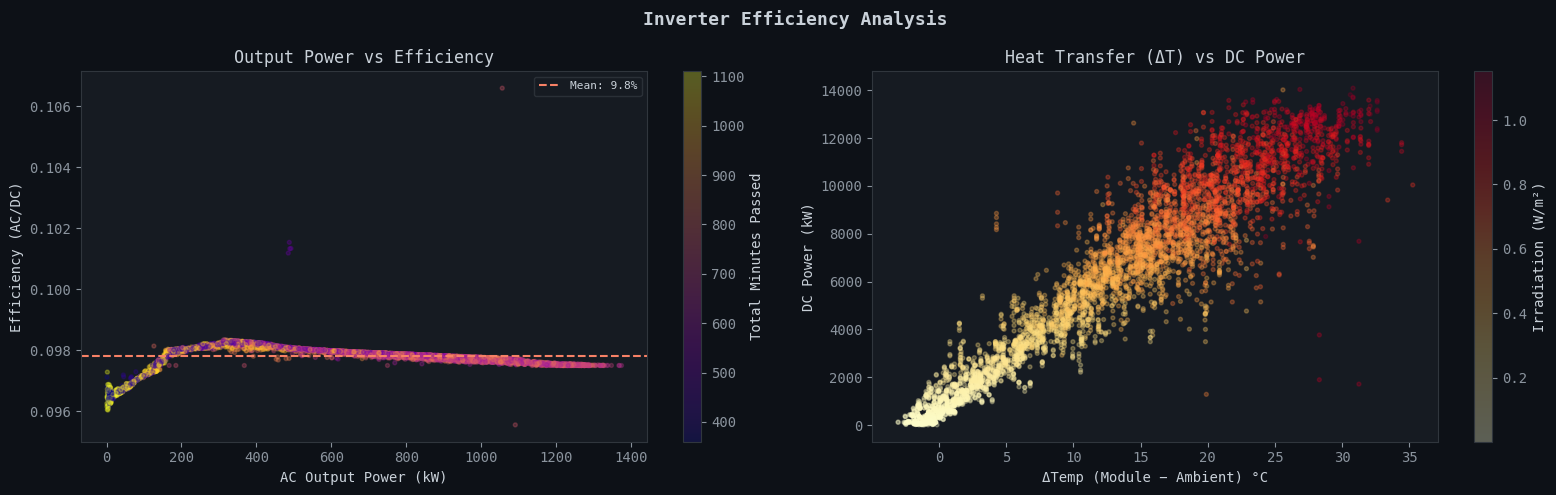

In [18]:
# ── Efficiency analysis ────────────────────────────────────────────────────
daytime = df[(df['AC_POWER'] > 0) & (df['DC_POWER'] > 0)].copy()
daytime['EFF_RATIO'] = (daytime['AC_POWER'] / daytime['DC_POWER']).clip(0, 1.05)
plant_eff = daytime['AC_POWER'].sum() / daytime['DC_POWER'].sum() * 100
print(f'Overall Plant Efficiency (AC/DC): {plant_eff:.3f}%')

fig, axes = plt.subplots(1, 2, figsize=(16,5))
fig.suptitle('Inverter Efficiency Analysis', fontsize=13, color='#c9d1d9', fontweight='bold')

sample = daytime.sample(min(5000,len(daytime)), random_state=SEED)

ax = axes[0]
sc = ax.scatter(sample['AC_POWER'], sample['EFF_RATIO'], alpha=0.3, s=8,
                c=sample['TOTAL_MINUTES_PASSED'], cmap='plasma', rasterized=True)
plt.colorbar(sc, ax=ax, label='Total Minutes Passed')
ax.axhline(plant_eff/100, color=C2, lw=1.5, ls='--', label=f'Mean: {plant_eff:.1f}%')
ax.set_xlabel('AC Output Power (kW)'); ax.set_ylabel('Efficiency (AC/DC)')
ax.set_title('Output Power vs Efficiency'); ax.legend(fontsize=8)

ax = axes[1]
sc2 = ax.scatter(sample['DELTA_TEMPERATURE'], sample['DC_POWER'], alpha=0.3, s=8,
                 c=sample['IRRADIATION'], cmap='YlOrRd', rasterized=True)
plt.colorbar(sc2, ax=ax, label='Irradiation (W/m²)')
ax.set_xlabel('ΔTemp (Module − Ambient) °C'); ax.set_ylabel('DC Power (kW)')
ax.set_title('Heat Transfer (ΔT) vs DC Power')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'10_efficiency.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

<div style="background:#0f3460;border-left:5px solid #e94560;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#e94560;font-size:1.2em;font-weight:bold;">Section 7 — ML Models: Linear Regression · Decision Tree · Random Forest (GridSearchCV)</span>
</div>

Three models trained in order of increasing complexity:

| Model | Key Trait |
|-------|----------|
| **Linear Regression** | Interpretable baseline; requires scaling |
| **Decision Tree** | Captures non-linearity; no scaling needed; prone to overfit |
| **Random Forest** | Ensemble of 200 trees; **hyperparameters tuned via GridSearchCV** |


In [19]:
# ── Safe ML feature set — verified leakage-free ──────────────────────────────
# EXCLUDED (leakage sources):
#   DC_POWER       : Spearman ρ=0.99 with AC_POWER → R²≈100% from this alone
#   DC_AC_RATIO    : DC/(AC+ε) contains target AC_POWER in denominator
#   EFFICIENCY     : AC/(IRRAD×1000) contains target AC_POWER in numerator
#   DAILY_YIELD    : cumulative within-day counter → look-ahead bias

# Make sure data is in correct time order
df = df.sort_values(['SOURCE_KEY', 'DATE_TIME'])

# Create future target (next time step)
df['TARGET'] = df.groupby('SOURCE_KEY')['AC_POWER'].shift(-1)

# Remove last rows (they have no future value)
df = df.dropna().reset_index(drop=True)

TARGET = 'TARGET'

ML_CANDIDATE_FEATURES = [
    'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION',
    'TOTAL_MINUTES_PASSED', 'HOUR', 'MONTH',
    'DELTA_TEMPERATURE',          # MODULE-AMBIENT; no target
    'IRRAD_X_MODULE',             # IRRAD×MODULE_TEMP; no target
    'SOURCE_KEY_NUM',
    'AC_POWER_ROLL3_MEAN',        # mean(AC[t-1],AC[t-2],AC[t-3]); shifted → safe
    'IRRADIATION_ROLL3_MEAN',     # past irradiation mean; safe
    'MODULE_TEMPERATURE_ROLL3_MEAN',
    'AC_POWER_LAG1',              # AC[t-1]; strictly past
    'AC_POWER_LAG3',              # AC[t-3]; strictly past
    'AC_POWER_LAG6',              # AC[t-6]; strictly past
]

ML_FEATURES = [f for f in ML_CANDIDATE_FEATURES if f in df.columns]
print(f'ML features ({len(ML_FEATURES)}): {ML_FEATURES}')

# ── Train/test split — NO shuffle (preserve time order) ────────────────────
X = df[ML_FEATURES].values
y = df[TARGET].values
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

def compute_metrics(y_true, y_pred, name=''):
    mask = y_true > 0   # keep only daytime values

    # Safe MAPE calculation (avoid division on empty mask)
    if mask.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    else:
        mape = np.nan

    m = {
        'MAE' : round(float(mean_absolute_error(y_true, y_pred)), 4),
        'RMSE': round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        'R2'  : round(float(r2_score(y_true, y_pred) * 100), 4),
        'MAPE': round(float(mape), 4),
    }

    if name:
        print(f'  {name:<28}  MAE={m["MAE"]:.3f}  RMSE={m["RMSE"]:.3f}  R²={m["R2"]:.2f}%  MAPE={m["MAPE"]:.2f}%')

    return m

ML features (15): ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'TOTAL_MINUTES_PASSED', 'HOUR', 'MONTH', 'DELTA_TEMPERATURE', 'IRRAD_X_MODULE', 'SOURCE_KEY_NUM', 'AC_POWER_ROLL3_MEAN', 'IRRADIATION_ROLL3_MEAN', 'MODULE_TEMPERATURE_ROLL3_MEAN', 'AC_POWER_LAG1', 'AC_POWER_LAG3', 'AC_POWER_LAG6']
Train: (55001, 15)  |  Test: (13751, 15)


In [20]:
# ── 1. Linear Regression (scaled) ─────────────────────────────────────────
scaler_lr    = StandardScaler()
X_train_sc   = scaler_lr.fit_transform(X_train)
X_test_sc    = scaler_lr.transform(X_test)          # ← fit on train only

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)                   # ← predict on test set
metrics_lr = compute_metrics(y_test, y_pred_lr, 'Linear Regression')

# ── 2. Decision Tree ───────────────────────────────────────────────────────
dt = DecisionTreeRegressor(max_depth=15, min_samples_split=10, random_state=SEED)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)                       # ← predict on test set
metrics_dt = compute_metrics(y_test, y_pred_dt, 'Decision Tree')

print('LR and DT trained ✓')

  Linear Regression             MAE=63.941  RMSE=113.400  R²=91.76%  MAPE=34.24%
  Decision Tree                 MAE=21.304  RMSE=61.281  R²=97.59%  MAPE=6.15%
LR and DT trained ✓


### 7.1 — Random Forest Hyperparameter Tuning (GridSearchCV)

We search over a focused grid using **TimeSeriesSplit** cross-validation (5 folds).  
`TimeSeriesSplit` is mandatory here — standard KFold would allow future data to leak  
into training folds, artificially inflating scores.

| Parameter | Values searched | Effect |
|-----------|----------------|--------|
| `n_estimators` | 100, 200 | More trees → lower variance |
| `max_depth` | 10, 20, None | Controls overfit |
| `min_samples_split` | 5, 10 | Min samples to split a node |
| `max_features` | `sqrt`, `log2` | Decorrelation between trees |


In [21]:
# ── GridSearchCV — Random Forest ──────────────────────────────────────────
param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [10, 20, None],
    'min_samples_split': [5, 10],
    'max_features'    : ['sqrt', 'log2'],
}

tscv = TimeSeriesSplit(n_splits=5)   # time-aware cross-validation

rf_base = RandomForestRegressor(n_jobs=-1, random_state=SEED)

gs = GridSearchCV(
    estimator   = rf_base,
    param_grid  = param_grid,
    cv          = tscv,
    scoring     = 'neg_root_mean_squared_error',
    n_jobs      = -1,
    verbose     = 1,
    refit       = True,              # refit best model on full train set
)

logger.info('Starting GridSearchCV ...')
gs.fit(X_train, y_train)
logger.info('GridSearchCV complete ✓')

print(f'\nBest parameters  : {gs.best_params_}')
print(f'Best CV RMSE     : {-gs.best_score_:.4f}')

02:21:40 | INFO | Starting GridSearchCV ...


Fitting 5 folds for each of 24 candidates, totalling 120 fits


02:22:21 | INFO | GridSearchCV complete ✓



Best parameters  : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best CV RMSE     : 39.8647


In [22]:
# ── Evaluate best RF model on test set ────────────────────────────────────
rf = gs.best_estimator_                 # best model already refitted on full X_train

y_pred_rf = rf.predict(X_test)

metrics_rf = compute_metrics(y_test, y_pred_rf, 'Random Forest (GridSearchCV)')

# Save model
joblib.dump(rf, MODEL_DIR / 'rf_model.pkl')
logger.info('RF model saved ✓')

print(f'\nTest set predictions shape : {y_pred_rf.shape}')
print(f'Test set actual shape      : {y_test.shape}')

02:22:21 | INFO | RF model saved ✓


  Random Forest (GridSearchCV)  MAE=13.136  RMSE=40.558  R²=98.95%  MAPE=3.96%

Test set predictions shape : (13751,)
Test set actual shape      : (13751,)


### 7.2 — Feature Importance Analysis

Two complementary methods:

| Method | How it works | Strength |
|--------|-------------|---------|
| **Gini Importance** | Mean decrease in node impurity across all trees | Fast; built-in |
| **Permutation Importance** | Shuffle each feature; measure accuracy drop | Model-agnostic; avoids bias toward high-cardinality features |

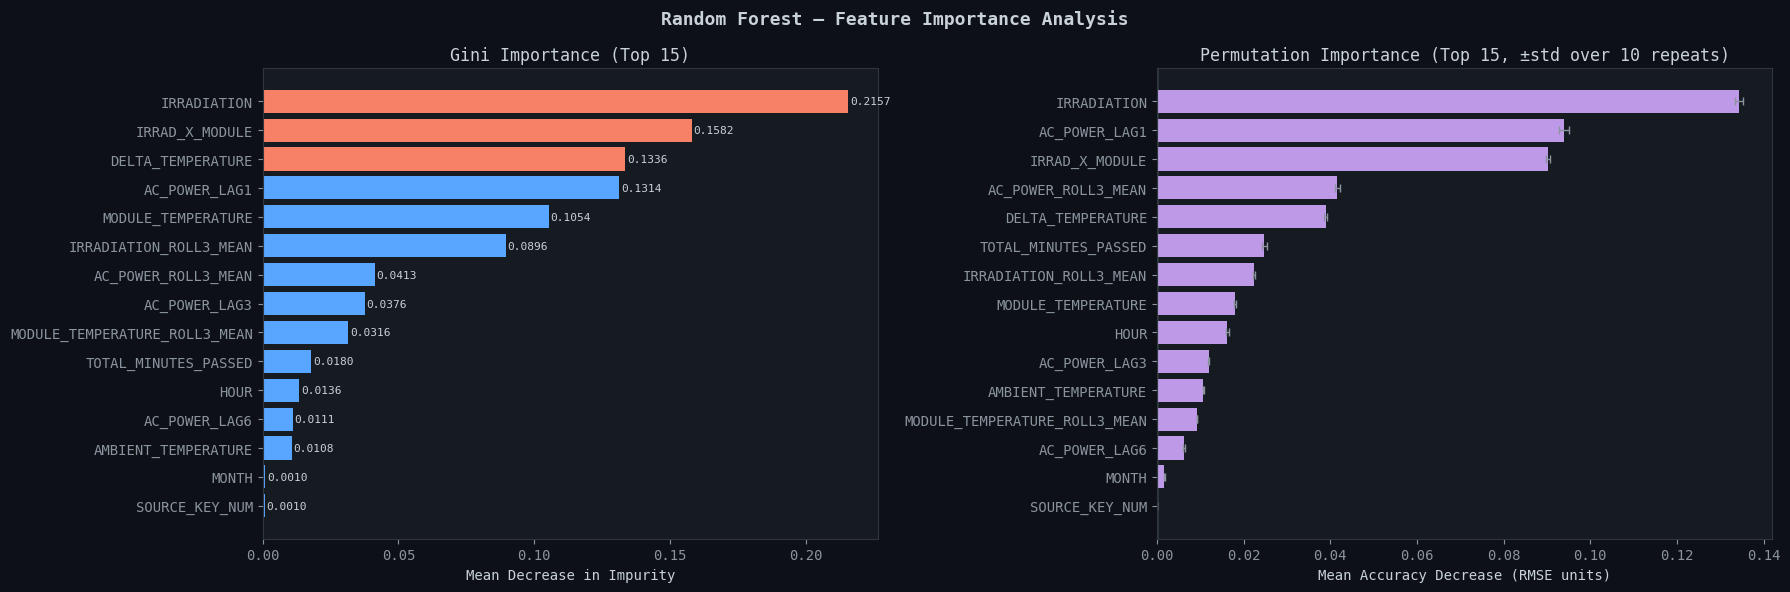


Top 5 features (Gini):
  IRRADIATION                         0.21572
  IRRAD_X_MODULE                      0.15823
  DELTA_TEMPERATURE                   0.13361
  AC_POWER_LAG1                       0.13141
  MODULE_TEMPERATURE                  0.10541


In [23]:
# ── Gini importance ────────────────────────────────────────────────────────
gini_imp = rf.feature_importances_
top_n    = 15
top_idx  = np.argsort(gini_imp)[-top_n:]
top_names = [ML_FEATURES[i] for i in top_idx]
top_vals  = gini_imp[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Random Forest — Feature Importance Analysis', fontsize=13,
             color='#c9d1d9', fontweight='bold')

# Gini importance bar
ax = axes[0]
bar_colors = [C2 if i >= top_n-3 else C1 for i in range(top_n)]
ax.barh(top_names, top_vals, color=bar_colors, edgecolor='none')
ax.set_title(f'Gini Importance (Top {top_n})')
ax.set_xlabel('Mean Decrease in Impurity')
for i, v in enumerate(top_vals):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=8)

# Permutation importance (subset for speed)
perm_res = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10, random_state=SEED, n_jobs=-1
)
perm_mean = perm_res.importances_mean
perm_std  = perm_res.importances_std

perm_idx   = np.argsort(perm_mean)[-top_n:]
perm_names = [ML_FEATURES[i] for i in perm_idx]
perm_vals  = perm_mean[perm_idx]
perm_errs  = perm_std[perm_idx]

ax = axes[1]
ax.barh(perm_names, perm_vals, xerr=perm_errs, color=C4,
        edgecolor='none', alpha=0.9, capsize=3,
        error_kw={'ecolor':'#8b949e','elinewidth':1})
ax.axvline(0, color='#8b949e', lw=1)
ax.set_title(f'Permutation Importance (Top {top_n}, ±std over 10 repeats)')
ax.set_xlabel('Mean Accuracy Decrease (RMSE units)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'11_feature_importance.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

print('\nTop 5 features (Gini):')
for n, v in sorted(zip(top_names, top_vals), key=lambda x: -x[1])[:5]:
    print(f'  {n:<35} {v:.5f}')

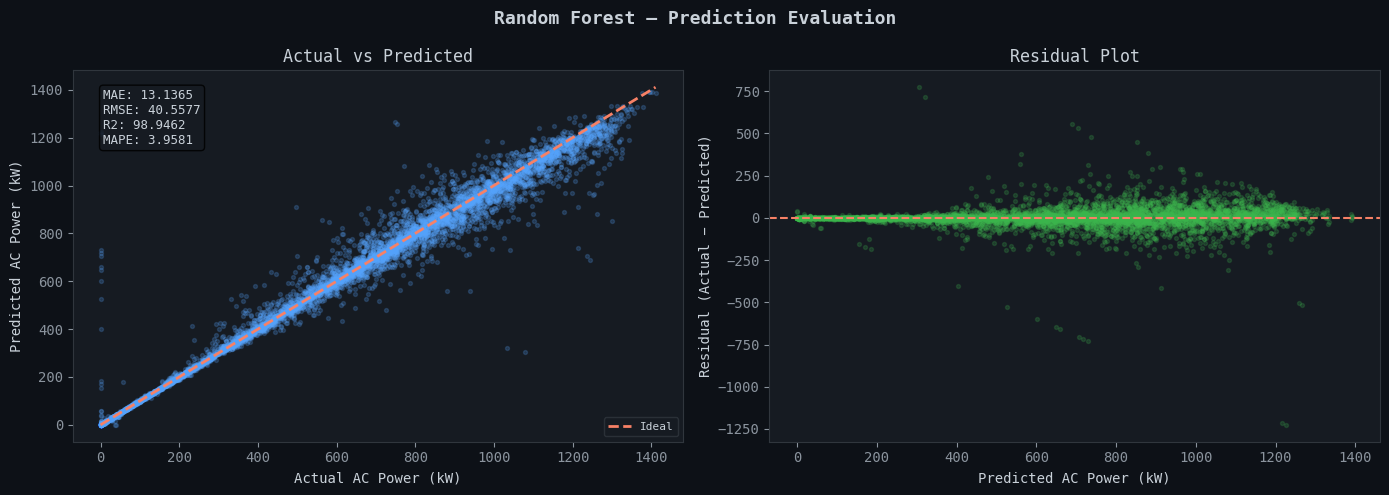

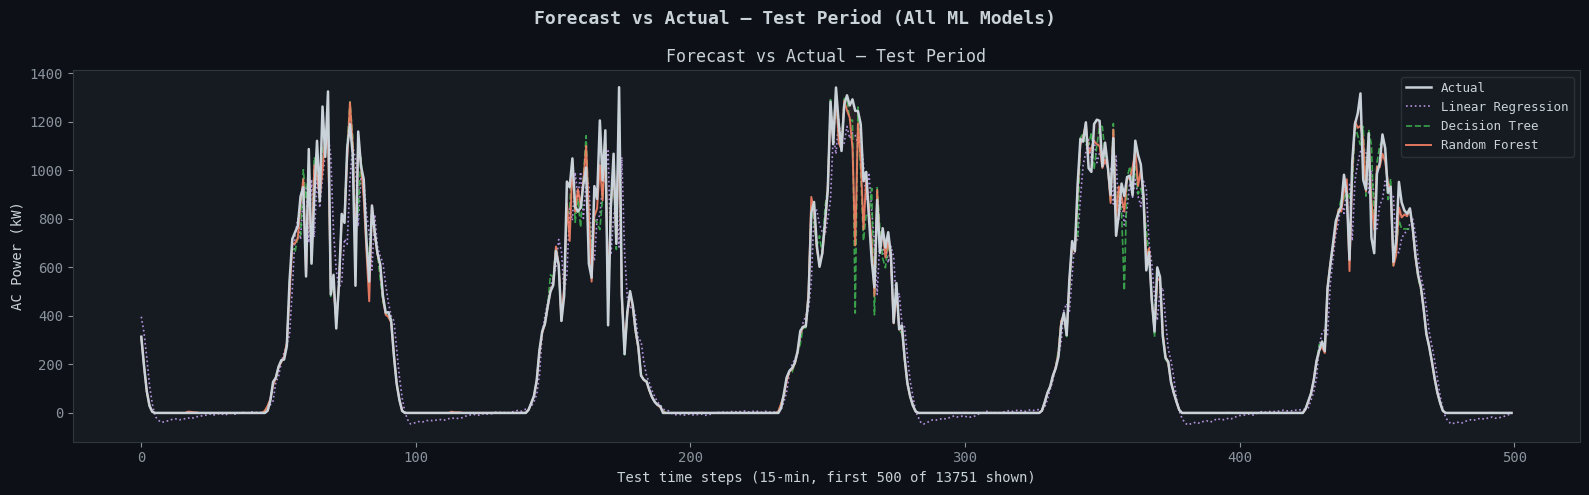

02:22:31 | INFO | Forecast vs Actual time-series plot saved ✓


In [24]:
# ── RF evaluation plots: scatter + residuals ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Prediction Evaluation', fontsize=13,
             color='#c9d1d9', fontweight='bold')

ax = axes[0]
ax.scatter(y_test, y_pred_rf, alpha=0.2, s=8, color=C1, rasterized=True)
lo, hi = float(min(y_test.min(), y_pred_rf.min())), float(max(y_test.max(), y_pred_rf.max()))
ax.plot([lo,hi],[lo,hi], color=C2, lw=2, ls='--', label='Ideal')
ax.set_xlabel('Actual AC Power (kW)'); ax.set_ylabel('Predicted AC Power (kW)')
ax.set_title('Actual vs Predicted'); ax.legend(fontsize=8)
txt = '\n'.join([f'{k}: {v}' for k, v in metrics_rf.items()])
ax.text(0.05, 0.95, txt, transform=ax.transAxes, va='top', fontsize=9,
        family='monospace', color='#c9d1d9',
        bbox=dict(boxstyle='round', facecolor=PANEL_BG, alpha=0.85))

ax = axes[1]
residuals = y_test - y_pred_rf
ax.scatter(y_pred_rf, residuals, alpha=0.2, s=8, color=C3, rasterized=True)
ax.axhline(0, color=C2, lw=1.5, ls='--')
ax.set_xlabel('Predicted AC Power (kW)'); ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residual Plot')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'12_rf_evaluation.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

# ── Forecast vs Actual — time-series overlay for ALL models ──────────────────
n_show = min(500, len(y_test))
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Forecast vs Actual — Test Period (All ML Models)',
             fontsize=13, color='#c9d1d9', fontweight='bold')

ax.plot(range(n_show), y_test[:n_show], color='#c9d1d9', lw=1.8,
        label='Actual', zorder=3)
ax.plot(range(n_show), y_pred_lr[:n_show], color=C4, lw=1.2, ls=':',
        alpha=0.85, label='Linear Regression')
ax.plot(range(n_show), y_pred_dt[:n_show], color=C3, lw=1.2, ls='--',
        alpha=0.85, label='Decision Tree')
ax.plot(range(n_show), y_pred_rf[:n_show], color=C2, lw=1.4,
        alpha=0.9,  label='Random Forest')
ax.fill_between(range(n_show), y_test[:n_show], y_pred_rf[:n_show],
                alpha=0.08, color=C2)
ax.set_xlabel(f'Test time steps (15-min, first {n_show} of {len(y_test)} shown)')
ax.set_ylabel('AC Power (kW)')
ax.set_title('Forecast vs Actual — Test Period')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '12b_all_models_forecast_vs_actual.png',
            dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
logger.info('Forecast vs Actual time-series plot saved ✓')


In [25]:
# ── Cross-check table ──────────────────────────────────────────────────────
cross_check = pd.DataFrame({
    'Actual'       : y_test,
    'Predicted_LR' : y_pred_lr,
    'Predicted_DT' : y_pred_dt,
    'Predicted_RF' : y_pred_rf,
})
cross_check['Error_LR'] = (cross_check['Actual'] - cross_check['Predicted_LR']).abs()
cross_check['Error_DT'] = (cross_check['Actual'] - cross_check['Predicted_DT']).abs()
cross_check['Error_RF'] = (cross_check['Actual'] - cross_check['Predicted_RF']).abs()

print(f'RF — Predictions within 5 kW  : {(cross_check["Error_RF"]<=5).mean()*100:.1f}%')
print(f'RF — Predictions within 20 kW : {(cross_check["Error_RF"]<=20).mean()*100:.1f}%')
cross_check.round(2).head(20).style.background_gradient(
    subset=['Error_LR','Error_DT','Error_RF'], cmap='RdYlGn_r')

RF — Predictions within 5 kW  : 68.8%
RF — Predictions within 20 kW : 82.8%


,Actual,Predicted_LR,Predicted_DT,Predicted_RF,Error_LR,Error_DT,Error_RF
0,314.140000,396.420000,309.380000,311.870000,82.280000,4.760000,2.260000
1,193.510000,329.840000,192.170000,190.630000,136.320000,1.340000,2.880000
2,89.320000,228.240000,86.240000,87.930000,138.920000,3.080000,1.400000
3,28.660000,113.990000,29.290000,29.150000,85.330000,0.630000,0.490000
4,4.840000,38.040000,4.590000,4.710000,33.200000,0.260000,0.130000
5,0.000000,-13.940000,0.000000,0.000000,13.940000,0.000000,0.000000
6,0.000000,-27.050000,0.000000,0.000000,27.050000,0.000000,0.000000
7,0.000000,-37.910000,0.000000,0.000000,37.910000,0.000000,0.000000
8,0.000000,-37.410000,0.000000,0.000000,37.410000,0.000000,0.000000
9,0.000000,-33.770000,0.000000,0.000000,33.770000,0.000000,0.000000


<div style="background:#0f3460;border-left:5px solid #e94560;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#e94560;font-size:1.2em;font-weight:bold;">Section 8 — SARIMA: Seasonal Time-Series Forecasting</span>
</div>

### Why SARIMA?

SARIMA (**Seasonal** AutoRegressive Integrated Moving Average) is the standard classical model for time-series with seasonal structure. Solar power generation has a strong **daily seasonal pattern** — the bell-curve peak at solar noon — making SARIMA a principled choice.

### Data Granularity: Hourly Aggregation (Primary)

| Granularity | Points | Seasonal Period | Diagnostics |
|-------------|--------|----------------|-------------|
| **Hourly** ⭐ | ~816 (34 days × 24h) | **s=24** (daily cycle) | ✅ Full diagnostics valid |
| Daily | 34 | s=7 (weekly cycle) | ⚠️ Too few for reliable inference |

We use **hourly plant-level AC_POWER totals** as the primary SARIMA input:
- Aggregating across all 22 inverters gives plant-level totals
- Flooring to the hour gives ~816 data points — sufficient for SARIMA fitting and full diagnostics
- `SARIMA(1,1,1)(1,1,0,24)`: AR1 + first-difference + MA1 with seasonal period=24

> A **daily alternative** (ARIMA with s=7) is also shown in Section 8b for comparison.  
> The web application lets users toggle between both with a single click.

In [26]:
# ── Build hourly plant-level series (target + weather exogenous features) ────
logger.info('Building hourly plant-level series (target + exogenous weather) ...')

df_hourly = df.copy()
df_hourly['HOUR_DT'] = df_hourly['DATE_TIME'].dt.floor('h')

EXOG_COLS = [c for c in ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']
             if c in df_hourly.columns]

hourly_df = (
    df_hourly.groupby('HOUR_DT')
             .agg({'AC_POWER': 'mean', **{c: 'mean' for c in EXOG_COLS}})
             .sort_index()
)

full_range = pd.date_range(hourly_df.index.min(), hourly_df.index.max(), freq='h')
hourly_df = hourly_df.reindex(full_range)
hourly_df.index.freq = 'h'

n_missing = hourly_df['AC_POWER'].isna().sum()
print(f'Missing hours (to be filled per-split, not here): {n_missing}')

hourly_series = hourly_df['AC_POWER'].rename('AC_POWER_HOURLY')
hourly_exog   = hourly_df[EXOG_COLS]

print(f'Hourly series shape : {hourly_series.shape}')
print(f'Exogenous features  : {EXOG_COLS}')
print(f'Date range : {hourly_series.index[0]} → {hourly_series.index[-1]}')
hourly_df.head(6)

02:22:31 | INFO | Building hourly plant-level series (target + exogenous weather) ...


Missing hours (to be filled per-split, not here): 20
Hourly series shape : (816,)
Exogenous features  : ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']
Date range : 2020-05-15 00:00:00 → 2020-06-17 23:00:00


,AC_POWER,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE
2020-05-15 00:00:00,0.000,0.000,25.013,22.643
2020-05-15 01:00:00,0.000,0.000,24.669,22.418
2020-05-15 02:00:00,0.000,0.000,24.987,23.512
2020-05-15 03:00:00,0.000,0.000,24.955,24.126
2020-05-15 04:00:00,0.000,0.000,24.272,22.128
2020-05-15 05:00:00,0.000,0.000,24.274,23.015


Train : 653 hours (27.2 days)
Test  : 163 hours (6.8 days)


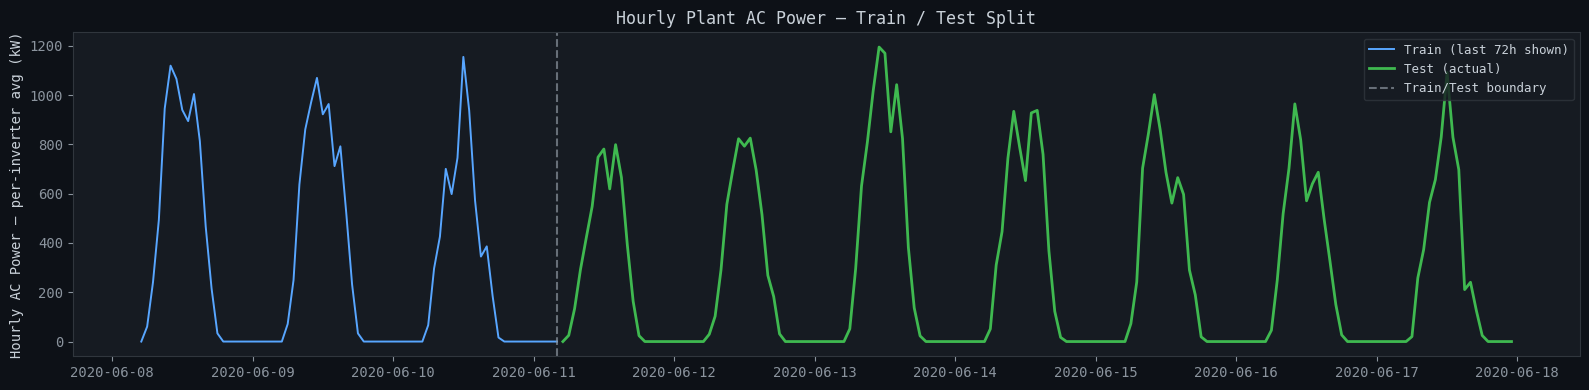

In [27]:
# ── Train / test split (80/20 temporal) ──────────────────────────────────────
SEASON     = 24   # daily cycle in hourly data
n_pts      = len(hourly_series)
n_test     = max(SEASON * 2, int(n_pts * 0.2))
n_train    = n_pts - n_test

train_s, test_s       = hourly_series.iloc[:n_train], hourly_series.iloc[n_train:]
train_exog, test_exog = hourly_exog.iloc[:n_train],   hourly_exog.iloc[n_train:]

train_s = train_s.interpolate(method='time').ffill().bfill()
test_s  = test_s.interpolate(method='time').ffill().bfill()
train_exog = train_exog.interpolate(method='time').ffill().bfill()
test_exog  = test_exog.interpolate(method='time').ffill().bfill()

print(f'Train : {n_train} hours ({n_train/24:.1f} days)')
print(f'Test  : {n_test} hours ({n_test/24:.1f} days)')

show_train = train_s.iloc[-72:]
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(show_train.index, show_train.values, color=C1, lw=1.4,
        label='Train (last 72h shown)')
ax.plot(test_s.index, test_s.values, color=C3, lw=2, label='Test (actual)')
ax.axvline(train_s.index[-1], color='#8b949e', lw=1.5, ls='--', alpha=0.7,
           label='Train/Test boundary')
ax.set_ylabel('Hourly AC Power — per-inverter avg (kW)')
ax.set_title('Hourly Plant AC Power — Train / Test Split')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '13_sarima_split.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()

In [28]:
logger.info('Selecting SARIMA order via AIC grid search (with exogenous weather) ...')

candidate_orders = [
    ((1, 1, 1), (1, 0, 0, 24)),
    ((1, 1, 1), (0, 1, 1, 24)),
    ((2, 1, 1), (1, 0, 0, 24)),
    ((1, 1, 2), (1, 0, 0, 24)),
    ((2, 1, 2), (1, 0, 0, 24)),
]

best_aic, best_order, best_sorder, sarima_result = np.inf, None, None, None
for order, sorder in candidate_orders:
    try:
        fit = SARIMAX(
            train_s, exog=train_exog,
            order=order, seasonal_order=sorder,
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False, maxiter=200)
        print(f'  order={order} seasonal={sorder}  AIC={fit.aic:.1f}')
        if fit.aic < best_aic:
            best_aic, best_order, best_sorder, sarima_result = fit.aic, order, sorder, fit
    except Exception as e:
        print(f'  order={order} seasonal={sorder}  FAILED ({e})')

logger.info(f'Best SARIMA order: {best_order}{best_sorder}  AIC={best_aic:.1f}')
print(sarima_result.summary().tables[0])
print(sarima_result.summary().tables[1])


02:22:31 | INFO | Selecting SARIMA order via AIC grid search (with exogenous weather) ...


  order=(1, 1, 1) seasonal=(1, 0, 0, 24)  AIC=5708.5
  order=(1, 1, 1) seasonal=(0, 1, 1, 24)  AIC=5346.3
  order=(2, 1, 1) seasonal=(1, 0, 0, 24)  AIC=5693.9
  order=(1, 1, 2) seasonal=(1, 0, 0, 24)  AIC=5699.5


02:22:40 | INFO | Best SARIMA order: (1, 1, 1)(0, 1, 1, 24)  AIC=5346.3


  order=(2, 1, 2) seasonal=(1, 0, 0, 24)  AIC=5689.8
                                     SARIMAX Results                                      
Dep. Variable:                    AC_POWER_HOURLY   No. Observations:                  653
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 24)   Log Likelihood               -2666.148
Date:                            Fri, 28 Aug 2026   AIC                           5346.296
Time:                                    02:22:40   BIC                           5377.098
Sample:                                05-15-2020   HQIC                          5358.285
                                     - 06-11-2020                                         
Covariance Type:                              opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
IRRADIATION          1240.0251     16.100  

02:22:40 | INFO | Lagging exog by 1 step for a fair, deployable comparison ...
02:22:42 | INFO | Running walk-forward SARIMA forecast (lagged exog) ...


SARIMA(1, 1, 1)(0, 1, 1, 24) + lagged exog, walk-forward — hourly metrics: {'MAE': 50.9901, 'RMSE': 90.3644, 'R2': 93.3524, 'MAPE': 31.3829}


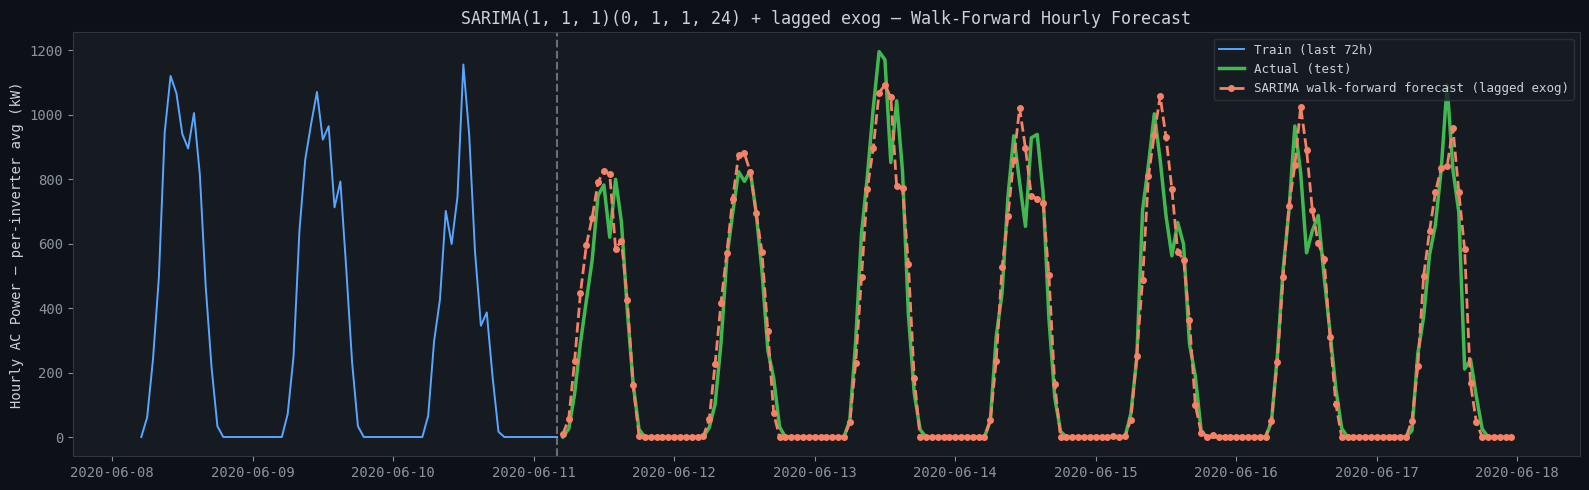


── Daily SARIMA alternative (s=7) — Section 8b ────────────────────────
  Daily ARIMA(1,1,1) + lagged exog metrics: {'MAE': 48.6419, 'RMSE': 50.6123, 'R2': -85.1079}


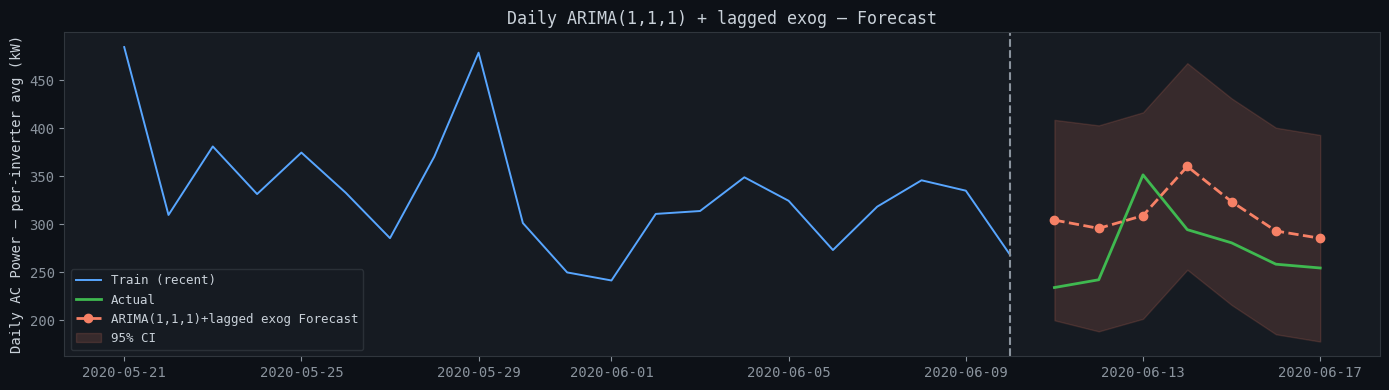

02:22:54 | INFO | Daily ARIMA fitted ✓


In [29]:
logger.info('Lagging exog by 1 step for a fair, deployable comparison ...')

train_exog_lagged = train_exog.shift(1).bfill()
test_exog_lagged  = test_exog.shift(1)
test_exog_lagged.iloc[0] = train_exog.iloc[-1]   # first test step uses last known train value

# Re-fit the chosen (order, seasonal_order) using LAGGED exog.
sarima_result_lagged = SARIMAX(
    train_s, exog=train_exog_lagged,
    order=best_order, seasonal_order=best_sorder,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False, maxiter=200)


logger.info('Running walk-forward SARIMA forecast (lagged exog) ...')

train_s_i = train_s.reset_index(drop=True)
test_s_i  = test_s.reset_index(drop=True)
test_s_i.index = range(len(train_s_i), len(train_s_i) + len(test_s_i))

train_exog_lagged_i = train_exog_lagged.reset_index(drop=True)
test_exog_lagged_i  = test_exog_lagged.reset_index(drop=True)
test_exog_lagged_i.index = test_s_i.index

sarima_result_i = SARIMAX(
    train_s_i, exog=train_exog_lagged_i,
    order=best_order, seasonal_order=best_sorder,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False, maxiter=200)

model_wf = sarima_result_i
preds = []
for t in test_s_i.index:
    fc = model_wf.get_forecast(steps=1, exog=test_exog_lagged_i.loc[[t]])
    preds.append(fc.predicted_mean.iloc[0])
    model_wf = model_wf.append(test_s_i.loc[[t]], exog=test_exog_lagged_i.loc[[t]], refit=False)

y_pred_sarima = np.clip(np.array(preds), 0, None)
y_true_sarima = test_s.values

mask_day = y_true_sarima > 0
mape_s   = (np.mean(np.abs((y_true_sarima[mask_day]-y_pred_sarima[mask_day])
                            /y_true_sarima[mask_day]))*100
            if mask_day.sum() > 0 else np.nan)

metrics_sarima = {
    'MAE' : round(float(mean_absolute_error(y_true_sarima, y_pred_sarima)), 4),
    'RMSE': round(float(np.sqrt(mean_squared_error(y_true_sarima, y_pred_sarima))), 4),
    'R2'  : round(float(r2_score(y_true_sarima, y_pred_sarima)*100), 4),
    'MAPE': round(float(mape_s), 4),
}
print(f'SARIMA{best_order}{best_sorder} + lagged exog, walk-forward — hourly metrics:', metrics_sarima)

# ── Forecast vs Actual plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(show_train.index, show_train.values, color=C1, lw=1.4,
        label='Train (last 72h)')
ax.plot(test_s.index, test_s.values,  color=C3, lw=2.5, label='Actual (test)')
ax.plot(test_s.index, y_pred_sarima,  color=C2, lw=2, ls='--',
        marker='o', ms=4, label='SARIMA walk-forward forecast (lagged exog)')
ax.axvline(train_s.index[-1], color='#8b949e', lw=1.5, ls='--', alpha=0.7)
ax.set_ylabel('Hourly AC Power — per-inverter avg (kW)')
ax.set_title(f'SARIMA{best_order}{best_sorder} + lagged exog — Walk-Forward Hourly Forecast')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '14_sarima_forecast.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()

# ── Daily SARIMA alternative (Section 8b) — same lagged-exog fix applied ─────
print('\n── Daily SARIMA alternative (s=7) — Section 8b ────────────────────────')
daily_df = (df.groupby('DATE_STR')
              .agg({'AC_POWER': 'mean', **{c: 'mean' for c in EXOG_COLS}})
              .sort_index())
daily_df.index = pd.to_datetime(daily_df.index)

full_range_d = pd.date_range(daily_df.index.min(), daily_df.index.max(), freq='D')
daily_df = daily_df.reindex(full_range_d)
daily_df.index.freq = 'D'

daily_series = daily_df['AC_POWER']
daily_exog   = daily_df[EXOG_COLS]

season_d  = 7
n_pts_d   = len(daily_series)
n_test_d  = max(season_d, int(n_pts_d * 0.2))
n_train_d = n_pts_d - n_test_d

train_d, test_d           = daily_series.iloc[:n_train_d], daily_series.iloc[n_train_d:]
train_exog_d, test_exog_d = daily_exog.iloc[:n_train_d],   daily_exog.iloc[n_train_d:]

# Interpolate each side separately (post-split, no cross-boundary leakage)
train_d = train_d.interpolate(method='time').ffill().bfill()
test_d  = test_d.interpolate(method='time').ffill().bfill()
train_exog_d = train_exog_d.interpolate(method='time').ffill().bfill()
test_exog_d  = test_exog_d.interpolate(method='time').ffill().bfill()

# Lag daily exog by 1 day too — same fairness fix as hourly
train_exog_d_lagged = train_exog_d.shift(1).bfill()
test_exog_d_lagged  = test_exog_d.shift(1)
test_exog_d_lagged.iloc[0] = train_exog_d.iloc[-1]

try:
    sarima_daily = SARIMAX(
        train_d, exog=train_exog_d_lagged,
        order=(1, 1, 1), seasonal_order=(0, 0, 0, 0),
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False, maxiter=200)

    fc_d     = sarima_daily.get_forecast(steps=n_test_d, exog=test_exog_d_lagged)
    yp_daily = np.clip(fc_d.predicted_mean.values, 0, None)
    fc_ci_d  = fc_d.conf_int(alpha=0.05)
    fc_ci_d.index = test_d.index

    m_daily = {
        'MAE' : round(float(mean_absolute_error(test_d.values, yp_daily)), 4),
        'RMSE': round(float(np.sqrt(mean_squared_error(test_d.values, yp_daily))), 4),
        'R2'  : round(float(r2_score(test_d.values, yp_daily)*100), 4),
    }
    print('  Daily ARIMA(1,1,1) + lagged exog metrics:', m_daily)

    show_train_d = train_d.iloc[-season_d*3:]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(show_train_d.index, show_train_d.values, color=C1, lw=1.4, label='Train (recent)')
    ax.plot(test_d.index, test_d.values, color=C3, lw=2, label='Actual')
    ax.plot(test_d.index, yp_daily, color=C2, lw=2, ls='--', marker='o', ms=6,
            label='ARIMA(1,1,1)+lagged exog Forecast')
    ax.fill_between(test_d.index,
                     np.clip(fc_ci_d.iloc[:, 0].values, 0, None),
                     fc_ci_d.iloc[:, 1].values,
                     color=C2, alpha=0.15, label='95% CI')
    ax.axvline(train_d.index[-1], color='#8b949e', linestyle='--')
    ax.set_ylabel('Daily AC Power — per-inverter avg (kW)')
    ax.set_title('Daily ARIMA(1,1,1) + lagged exog — Forecast')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '14b_sarima_daily_forecast.png',
                dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    logger.info('Daily ARIMA fitted ✓')
except Exception as e:
    logger.warning(f'Daily ARIMA failed: {e}')

02:22:54 | INFO | Generating SARIMA diagnostics ...


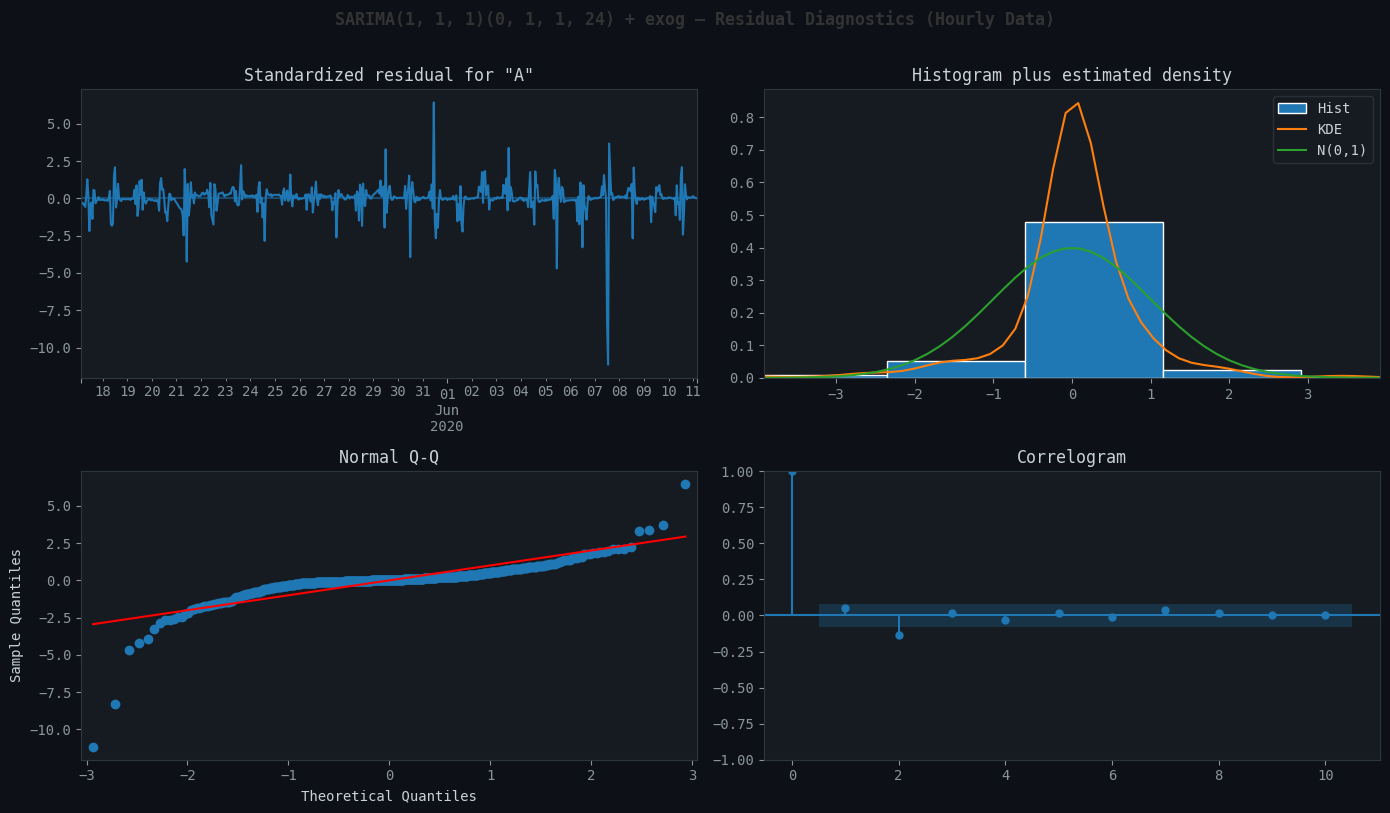

02:22:54 | INFO | Diagnostics saved → outputs/15_sarima_diagnostics.png
02:22:54 | INFO | Generating DAILY residual diagnostics ...


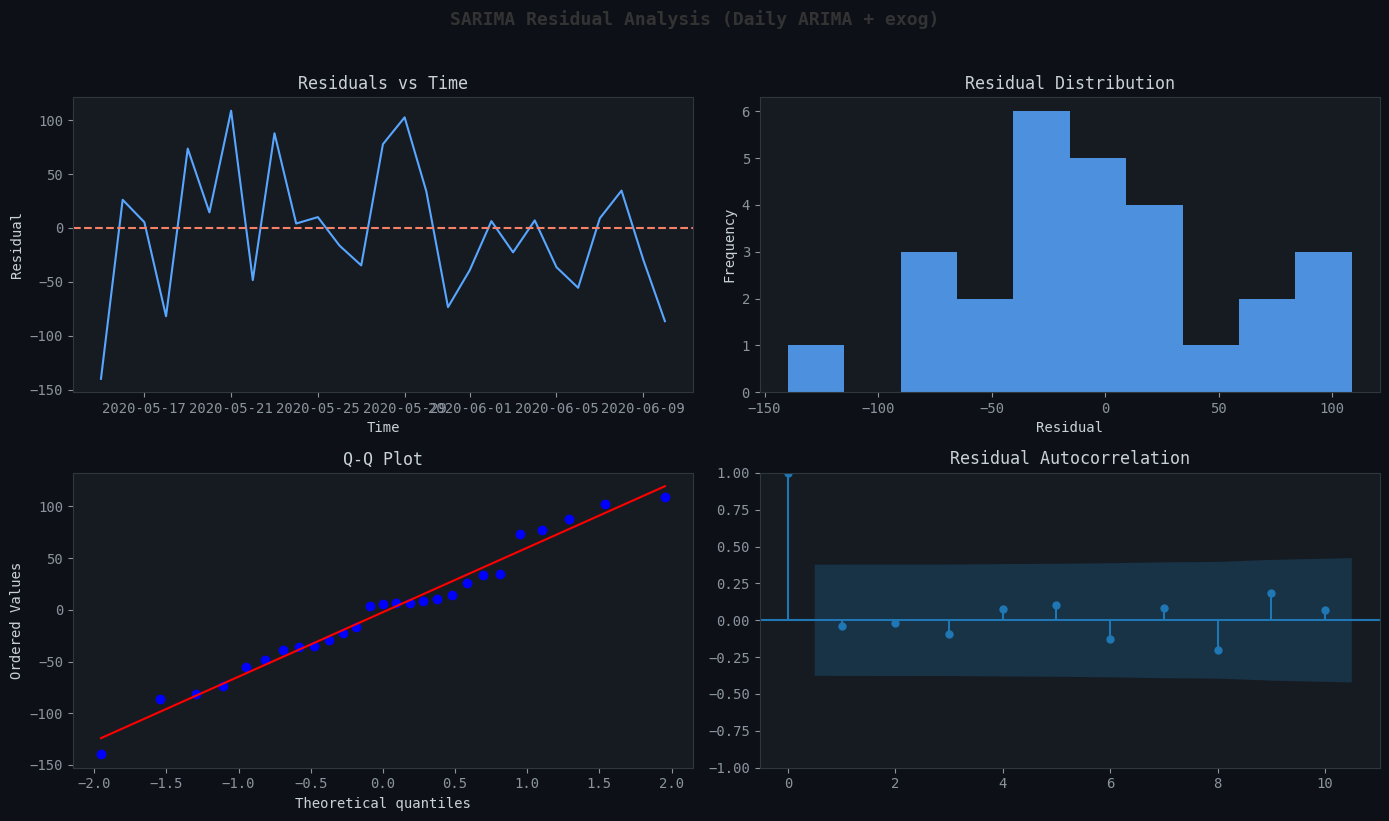

02:22:55 | INFO | Daily diagnostics saved ✓


In [30]:
# ── Full SARIMA diagnostics ─────────────────────────────────────────
# Diagnostics use `sarima_result`, the best-AIC model fit on the training set
#   Panel 1 (Standardised residuals): should show no pattern/trend
#   Panel 2 (Histogram + KDE)       : residuals should approximate normal
#   Panel 3 (Normal Q-Q)            : points should follow the diagonal line
#   Panel 4 (ACF correlogram)       : no significant lags after model fit
logger.info('Generating SARIMA diagnostics ...')
fig_diag = sarima_result.plot_diagnostics(figsize=(14, 8))
fig_diag.suptitle(f'SARIMA{best_order}{best_sorder} + exog — Residual Diagnostics (Hourly Data)',
                   fontsize=12, y=1.01, color='#333', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '15_sarima_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info('Diagnostics saved → outputs/15_sarima_diagnostics.png')

# ── Daily ARIMA residual diagnostics ────────────────────────────────────────
logger.info('Generating DAILY residual diagnostics ...')

import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

residuals = sarima_daily.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) Residuals vs Time
axes[0, 0].plot(residuals, color=C1)
axes[0, 0].axhline(0, color=C2, linestyle='--')
axes[0, 0].set_title('Residuals vs Time')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Residual')

# 2) Histogram
axes[0, 1].hist(residuals, bins=10, color=C1, alpha=0.85, edgecolor='none')
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')

# 3) Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')

# 4) ACF Plot
plot_acf(residuals, lags=10, ax=axes[1, 1])
axes[1, 1].set_title('Residual Autocorrelation')

fig.suptitle('SARIMA Residual Analysis (Daily ARIMA + exog)',
             fontsize=13, y=1.02,
             color='#333', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '15b_sarima_daily_diagnostics.png',
            dpi=150, bbox_inches='tight')
plt.show()

logger.info('Daily diagnostics saved ✓')


<div style="background:#0f3460;border-left:5px solid #e94560;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#e94560;font-size:1.2em;font-weight:bold;">Section 9 — LSTM: Deep Learning Time-Series Model</span>
</div>

### Architecture
```
Input (24 timesteps × N features)
    │
LSTM(128, return_sequences=True) → Dropout(0.2) → BatchNorm
    │
LSTM(64,  return_sequences=False) → Dropout(0.2) → BatchNorm
    │
Dense(32, relu) → Dense(1)
```

| Design Choice | Value | Reason |
|---------------|-------|--------|
| Loss | **Huber** | Robust to large nighttime zero-power outliers |
| Sequence | **24 steps (~6h)** | Covers a full morning ramp |
| LR schedule | **ReduceLROnPlateau** | Halves LR when val_loss plateaus |
| Stopping | **EarlyStopping(patience=8)** | Restores best weights automatically |


In [31]:
# ── LSTM feature config ────────────────────────────────────────────────────
SEQUENCE_LEN = 24

LSTM_CANDS = [
    'AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION',
    'DELTA_TEMPERATURE','IRRAD_X_MODULE','TOTAL_MINUTES_PASSED',
    'AC_POWER_ROLL3_MEAN','IRRADIATION_ROLL3_MEAN',
    'AC_POWER_LAG1','AC_POWER_LAG3',
]
LSTM_FEATURES = [f for f in LSTM_CANDS if f in df.columns]
print(f'LSTM features ({len(LSTM_FEATURES)}): {LSTM_FEATURES}')

def make_sequences(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(len(X_arr) - seq_len):
        Xs.append(X_arr[i:i+seq_len])
        ys.append(y_arr[i+seq_len])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

sort_keys = (['SOURCE_KEY','DATE_TIME'] if 'SOURCE_KEY' in df.columns else ['DATE_TIME'])
df_sorted  = df.sort_values(sort_keys).reset_index(drop=True)

scaler_X = MinMaxScaler(); scaler_y = MinMaxScaler()
X_sc = scaler_X.fit_transform(df_sorted[LSTM_FEATURES].values.astype(np.float32))
y_sc = scaler_y.fit_transform(df_sorted[[TARGET]].values.astype(np.float32)).ravel()

X_seq, y_seq = make_sequences(X_sc, y_sc, SEQUENCE_LEN)
split = int(0.8 * len(X_seq))
X_tr_l, X_te_l = X_seq[:split], X_seq[split:]
y_tr_l, y_te_l = y_seq[:split], y_seq[split:]
print(f'LSTM train: {X_tr_l.shape}  |  test: {X_te_l.shape}')

LSTM features (10): ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'DELTA_TEMPERATURE', 'IRRAD_X_MODULE', 'TOTAL_MINUTES_PASSED', 'AC_POWER_ROLL3_MEAN', 'IRRADIATION_ROLL3_MEAN', 'AC_POWER_LAG1', 'AC_POWER_LAG3']
LSTM train: (54982, 24, 10)  |  test: (13746, 24, 10)


In [32]:
# ── Build LSTM ─────────────────────────────────────────────────────────────
lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQUENCE_LEN, len(LSTM_FEATURES))),
    Dropout(0.2), BatchNormalization(),
    LSTM(64,  return_sequences=False),
    Dropout(0.2), BatchNormalization(),
    Dense(32, activation='relu'),
    Dense(1),
])
lstm.compile(optimizer=Adam(learning_rate=1e-3), loss='huber', metrics=['mae'])
lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,457 (482.25 KB)

 Trainable params: 123,073 (480.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [33]:
# ── Train ──────────────────────────────────────────────────────────────────

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        str(MODEL_DIR / 'lstm_best.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
]

history = lstm.fit(
    X_tr_l,
    y_tr_l,
    epochs=50,
    batch_size=64,
    validation_data=(X_te_l, y_te_l),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - loss: 0.0149 - mae: 0.1162 - val_loss: 0.0048 - val_mae: 0.0652 - learning_rate: 0.0010
Epoch 2/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0060 - mae: 0.0737 - val_loss: 0.0048 - val_mae: 0.0695 - learning_rate: 0.0010
Epoch 3/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 0.0054 - mae: 0.0680 - val_loss: 0.0041 - val_mae: 0.0567 - learning_rate: 0.0010
Epoch 4/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 0.0050 - mae: 0.0637 - val_loss: 0.0042 - val_mae: 0.0599 - learning_rate: 0.0010
Epoch 5/50
859/860 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0047 - mae: 0.0602
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0047 - mae: 0.0602 - val_loss: 0.0040 - val_mae: 0.0581 - learning_rate: 0.0010
Epoch 6/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 0.0042 - mae: 0.0556 - val_loss: 0.0039 - val_mae: 0.0462 - learning_ra

  LSTM                          MAE=28.976  RMSE=62.045  R²=97.53%  MAPE=16.36%


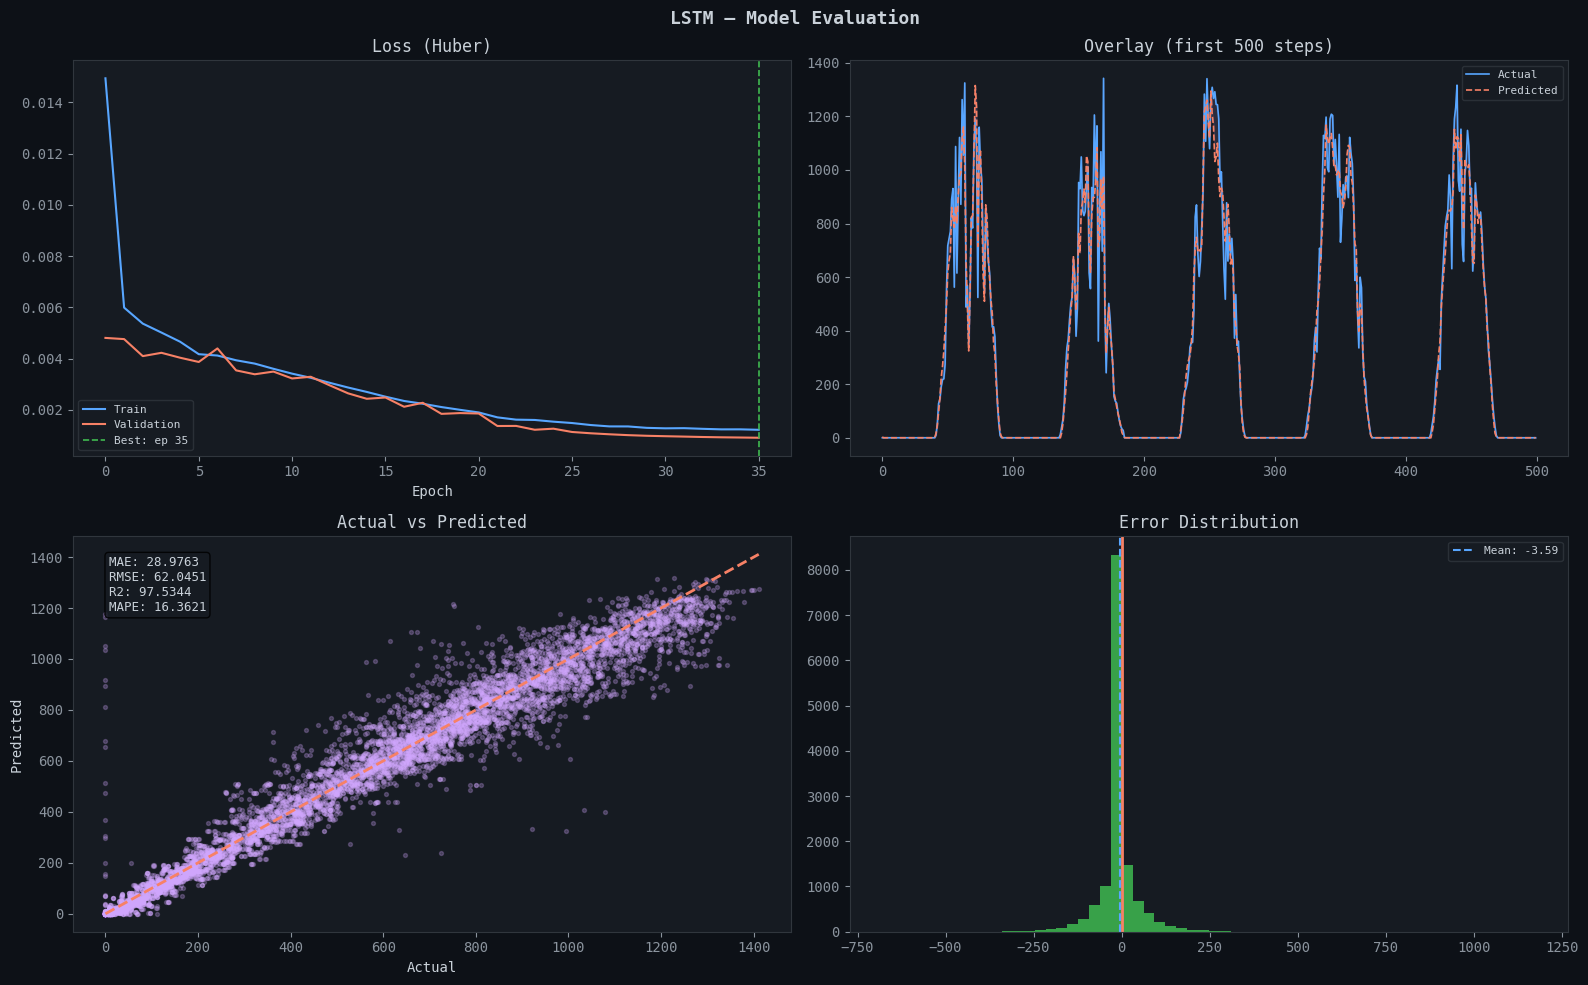

02:34:01 | INFO | LSTM saved ✓


In [34]:
# ── Evaluate & plot ─────────────────────────────────────────────────────────
y_pred_sc   = lstm.predict(X_te_l, verbose=0).ravel()
y_pred_lstm = np.clip(scaler_y.inverse_transform(y_pred_sc.reshape(-1,1)).ravel(), 0, None)
y_true_lstm = scaler_y.inverse_transform(y_te_l.reshape(-1,1)).ravel()
metrics_lstm = compute_metrics(y_true_lstm, y_pred_lstm, 'LSTM')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('LSTM — Model Evaluation', fontsize=13, color='#c9d1d9', fontweight='bold')

# Loss curves
ax = axes[0,0]
ax.plot(history.history['loss'],     color=C1, lw=1.5, label='Train')
ax.plot(history.history['val_loss'], color=C2, lw=1.5, label='Validation')
best_ep = int(np.argmin(history.history['val_loss']))
ax.axvline(best_ep, color=C3, lw=1.2, ls='--', label=f'Best: ep {best_ep}')
ax.set_title('Loss (Huber)'); ax.set_xlabel('Epoch'); ax.legend(fontsize=8)

# Time-series overlay
ax = axes[0,1]
n = min(500, len(y_true_lstm))
ax.plot(y_true_lstm[:n], color=C1, lw=1.2, label='Actual')
ax.plot(y_pred_lstm[:n], color=C2, lw=1.2, ls='--', label='Predicted')
ax.fill_between(range(n), y_true_lstm[:n], y_pred_lstm[:n], alpha=0.12, color=C4)
ax.set_title(f'Overlay (first {n} steps)'); ax.legend(fontsize=8)

# Scatter
ax = axes[1,0]
ax.scatter(y_true_lstm, y_pred_lstm, alpha=0.25, s=8, color=C4, rasterized=True)
lo, hi = float(min(y_true_lstm.min(),y_pred_lstm.min())), float(max(y_true_lstm.max(),y_pred_lstm.max()))
ax.plot([lo,hi],[lo,hi], color=C2, lw=2, ls='--')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted'); ax.set_title('Actual vs Predicted')
txt = '\n'.join([f'{k}: {v}' for k,v in metrics_lstm.items()])
ax.text(0.05, 0.95, txt, transform=ax.transAxes, va='top', fontsize=9,
        family='monospace', color='#c9d1d9',
        bbox=dict(boxstyle='round', facecolor=PANEL_BG, alpha=0.85))

# Error distribution
ax = axes[1,1]
errors = y_pred_lstm - y_true_lstm
ax.hist(errors, bins=60, color=C3, alpha=0.85, edgecolor='none')
ax.axvline(0, color=C2, lw=2)
ax.axvline(errors.mean(), color=C1, lw=1.5, ls='--', label=f'Mean: {errors.mean():.2f}')
ax.set_title('Error Distribution'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'16_lstm_evaluation.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

lstm.save(MODEL_DIR/'lstm_model.keras')
joblib.dump(scaler_X, MODEL_DIR/'lstm_scaler_X.pkl')
joblib.dump(scaler_y, MODEL_DIR/'lstm_scaler_y.pkl')
logger.info('LSTM saved ✓')

<div style="background:#0f3460;border-left:5px solid #e94560;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#e94560;font-size:1.2em;font-weight:bold;">Section 10 — All-Model Comparison & Final Report</span>
</div>


In [35]:
# ── All-model results table ────────────────────────────────────────────────
all_metrics = {
    'Linear Regression'           : metrics_lr,
    'Decision Tree'               : metrics_dt,
    'Random Forest (GridSearchCV)': metrics_rf,
    'SARIMA (daily scale)'        : metrics_sarima,
    'LSTM'                        : metrics_lstm,
}
m_colors = [C4, C3, C1, C2, '#ffa500']

print('\n' + '═'*72)
print('  SOLAR POWER FORECASTING — FINAL RESULTS')
print('═'*72)
print(f'  {"Model":<34}  {"MAE":>8}  {"RMSE":>8}  {"R²(%)":>8}  {"MAPE(%)":>9}')
print('  ' + '─'*68)
for name, m in all_metrics.items():
    print(f'  {name:<34}  {m["MAE"]:>8.3f}  {m["RMSE"]:>8.3f}  {m["R2"]:>8.2f}  {m["MAPE"]:>9.2f}')
print('─'*72)

# Best among ML+LSTM models (same scale)
ml_lstm = {k:v for k,v in all_metrics.items() if 'SARIMA' not in k}
winner  = min(ml_lstm, key=lambda m: ml_lstm[m]['RMSE'])
print(f'  🏆 Best ML/LSTM model (RMSE): {winner}')
print('═'*72)


════════════════════════════════════════════════════════════════════════
  SOLAR POWER FORECASTING — FINAL RESULTS
════════════════════════════════════════════════════════════════════════
  Model                                    MAE      RMSE     R²(%)    MAPE(%)
  ────────────────────────────────────────────────────────────────────
  Linear Regression                     63.941   113.400     91.76      34.24
  Decision Tree                         21.304    61.281     97.59       6.15
  Random Forest (GridSearchCV)          13.136    40.558     98.95       3.96
  SARIMA (daily scale)                  50.990    90.364     93.35      31.38
  LSTM                                  28.976    62.045     97.53      16.36
────────────────────────────────────────────────────────────────────────
  🏆 Best ML/LSTM model (RMSE): Random Forest (GridSearchCV)
════════════════════════════════════════════════════════════════════════


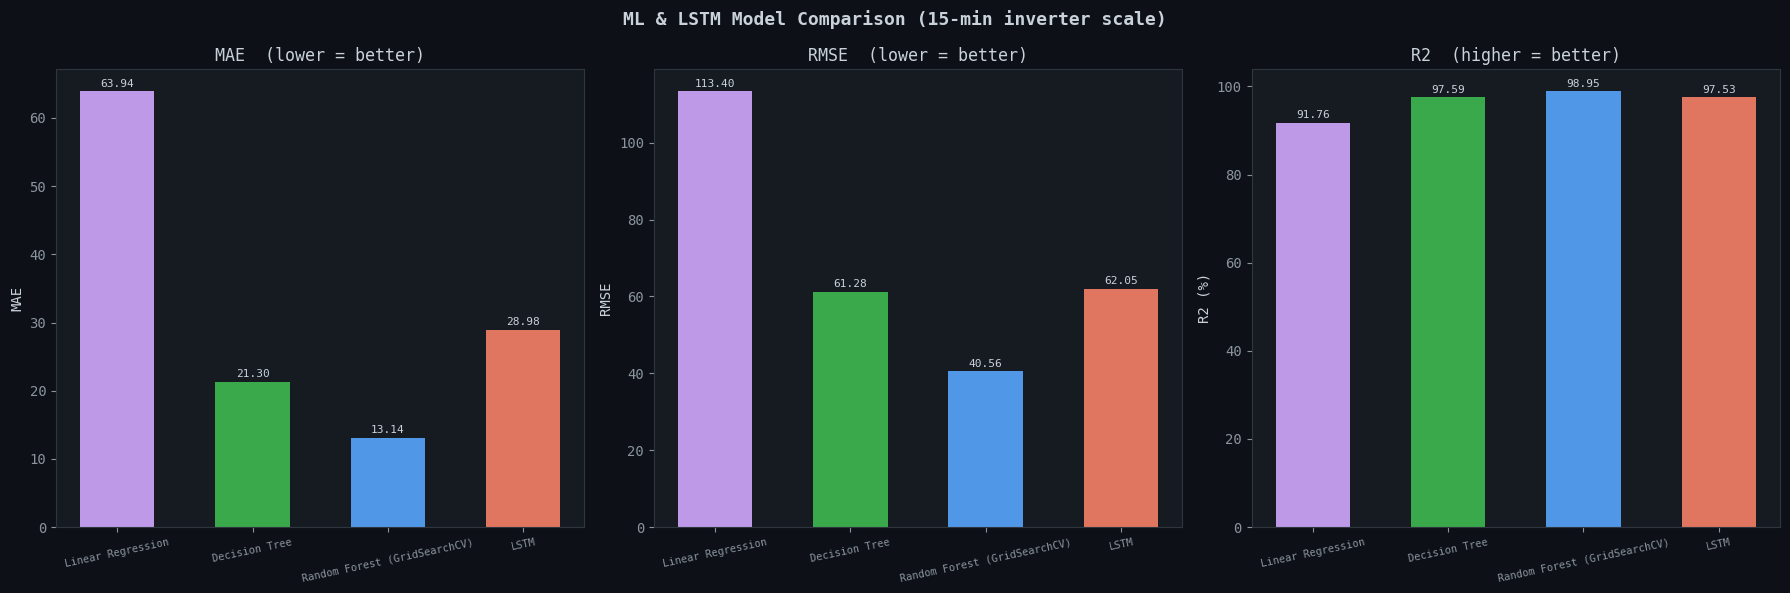

In [36]:
# ── Comparison bar charts (ML+LSTM models, same scale) ────────────────────
ml_names   = list(ml_lstm.keys())
ml_colors  = [C4, C3, C1, C2]

fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.suptitle('ML & LSTM Model Comparison (15-min inverter scale)',
             fontsize=13, color='#c9d1d9', fontweight='bold')

for ax, metric in zip(axes, ['MAE','RMSE','R2']):
    vals = [ml_lstm[m][metric] for m in ml_names]
    bars = ax.bar(ml_names, vals, color=ml_colors, edgecolor='none', alpha=0.9, width=0.55)
    ax.set_title(f'{metric}  ({"higher" if metric=="R2" else "lower"} = better)')
    ax.set_ylabel(metric + (' (%)' if metric=='R2' else ''))
    ax.tick_params(axis='x', labelsize=7.5, rotation=12)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+max(vals)*0.01,
                f'{v:.2f}', ha='center', fontsize=8, color='#c9d1d9')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'17_final_comparison.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

In [37]:
# ── Save JSON report ───────────────────────────────────────────────────────
report = {
    'generated_at': datetime.now().isoformat(),
    'dataset': {
        'clean_rows': len(df),
        'features'  : len(df.columns),
        'date_range': [str(df['DATE_TIME'].min()), str(df['DATE_TIME'].max())],
        'inverters' : int(df['SOURCE_KEY'].nunique()) if 'SOURCE_KEY' in df.columns else 1,
    },
    'best_rf_params' : gs.best_params_,
    'best_rf_cv_rmse': float(-gs.best_score_),
    'models': all_metrics,
    'winner_ml_lstm': winner,
}

path = OUTPUT_DIR / f'metrics_report{PLANT_ID}.json'
with open(path, 'w') as f:
    json.dump(report, f, indent=2)

print(f'Report saved → {path}')
print('\nOutputs summary:')
for p in sorted(OUTPUT_DIR.glob('*.png')):
    print(f'  {p.name}')
print(f'  {path.name}')
print('\nModels saved:')
for p in sorted(MODEL_DIR.glob('*')):
    print(f'  {p.name}')

Report saved → outputs/metrics_report1.json

Outputs summary:
  01_correlation.png
  02_distributions.png
  03_pairplot.png
  04_daywise_dc_power.png
  05_daily_totals.png
  06_best_vs_worst.png
  07_weather_trends.png
  08_seasonal_decomp.png
  09_module_temp_boxes.png
  10_efficiency.png
  11_feature_importance.png
  12_rf_evaluation.png
  12b_all_models_forecast_vs_actual.png
  13_sarima_split.png
  14_sarima_forecast.png
  14b_sarima_daily_forecast.png
  15_sarima_diagnostics.png
  15b_sarima_daily_diagnostics.png
  16_lstm_evaluation.png
  17_final_comparison.png
  plant_comparison.png
  metrics_report1.json

Models saved:
  lstm_best.keras
  lstm_model.keras
  lstm_scaler_X.pkl
  lstm_scaler_y.pkl
  rf_model.pkl


<div style="background:#0f3460;border-left:5px solid #e94560;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#e94560;font-size:1.2em;font-weight:bold;">Section 10b — Plant 1 vs Plant 2 Comparative Analysis</span>
</div>

Run this section **after running the full pipeline for both plants** and saving their metrics.
This cell loads both JSON reports and produces a head-to-head comparison.

> 💡 Run the notebook with `PLANT_ID = 1`, save outputs to `outputs/`, rename `metrics_report.json` → `metrics_plant1.json`.  
> Then run with `PLANT_ID = 2`, rename → `metrics_plant2.json`. Then run this cell.


── Plant 1 vs Plant 2 — Random Forest Comparison ─────────────────
  Metric       Plant 1     Plant 2      Better
  ────────────────────────────────────────────
  MAE           13.136      28.388     Plant 1
  RMSE          40.558     101.705     Plant 1
  R2            98.946      91.704     Plant 1
  MAPE           3.958       9.503     Plant 1


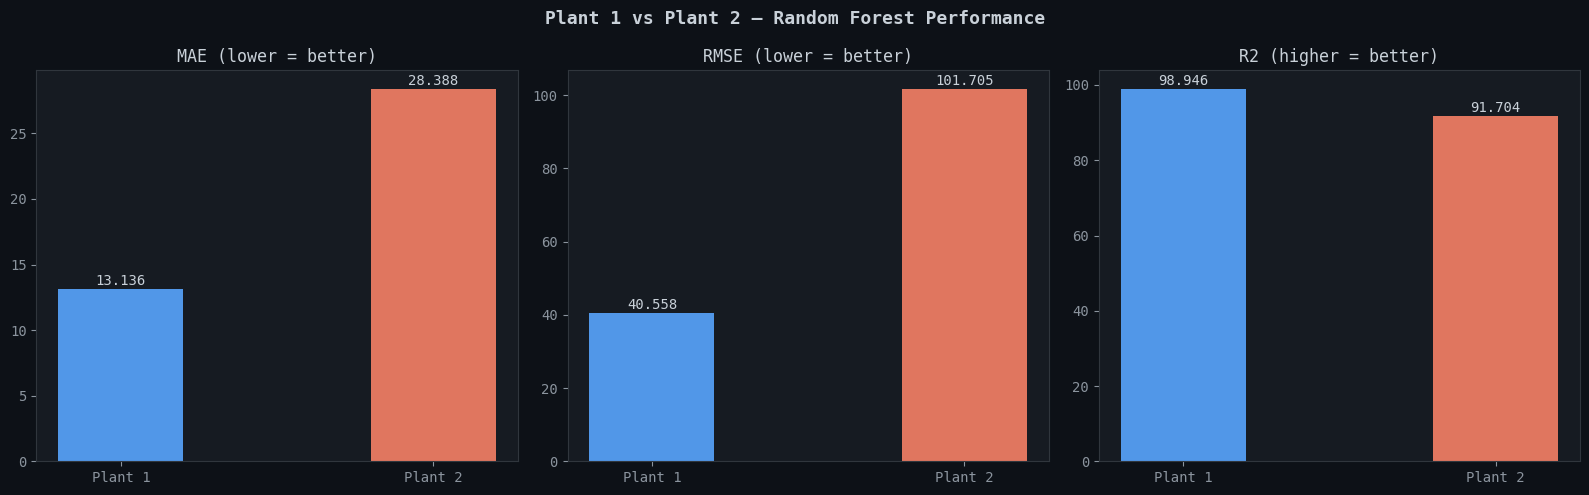

02:34:02 | INFO | Plant comparison plot saved ✓


In [38]:
# ── Load both plant reports (run pipeline for each plant first) ──────────────
p1_path = OUTPUT_DIR / 'metrics_report1.json'
p2_path = OUTPUT_DIR / 'metrics_report2.json'

if not (p1_path.exists() and p2_path.exists()):
    print('Missing report files. Run pipeline for both plants first:')
    print('  1. Set PLANT_ID=1, run all cells, rename metrics_report.json → metrics_plant1.json')
    print('  2. Set PLANT_ID=2, run all cells, rename metrics_report.json → metrics_plant2.json')
else:
    with open(p1_path) as f: r1 = json.load(f)
    with open(p2_path) as f: r2 = json.load(f)

    # ── Side-by-side RF comparison ────────────────────────────────────────────
    rf_key = [k for k in r1['models'] if 'Random Forest' in k][0]
    rf1    = r1['models'][rf_key]
    rf2    = r2['models'][rf_key]

    print('\n── Plant 1 vs Plant 2 — Random Forest Comparison ─────────────────')
    print(f'  {"Metric":<8}  {"Plant 1":>10}  {"Plant 2":>10}  {"Better":>10}')
    print('  ' + '─'*44)
    for k in ['MAE','RMSE','R2','MAPE']:
        v1, v2 = rf1[k], rf2[k]
        better = 'Plant 1' if (v1 < v2 if k != 'R2' else v1 > v2) else 'Plant 2'
        print(f'  {k:<8}  {v1:>10.3f}  {v2:>10.3f}  {better:>10}')

    # ── Visualisation ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Plant 1 vs Plant 2 — Random Forest Performance', fontsize=13,
                 color='#c9d1d9', fontweight='bold')

    for ax, metric in zip(axes, ['MAE','RMSE','R2']):
        vals   = [rf1[metric], rf2[metric]]
        labels = ['Plant 1', 'Plant 2']
        colors = [C1, C2]
        bars   = ax.bar(labels, vals, color=colors, edgecolor='none', alpha=0.9, width=0.4)
        ax.set_title(f'{metric} ({"higher" if metric=="R2" else "lower"} = better)')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+max(vals)*0.01,
                    f'{v:.3f}', ha='center', fontsize=10, color='#c9d1d9')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'plant_comparison.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    logger.info('Plant comparison plot saved ✓')

### 🔍 Why Plant 2 Underperforms Plant 1 — Data Quality Investigation

Every model tested (Linear Regression, Decision Tree, Random Forest, SARIMA, LSTM) scored
consistently worse on Plant 2 than Plant 1 — not just one model, but all five. That pattern
points to a data characteristic rather than a model or tuning issue, so a direct data-quality
comparison was run between the two plants.

**Comparison results:**

| Metric | Plant 1 | Plant 2 |
|---|---:|---:|
| IRRADIATION ↔ AC_POWER correlation | **0.9893** | **0.7809** |
| Rows | 68,774 | 67,698 |
| Mean daily CoV | 0.6623 | 0.5970 |
| High-fault days (CoV > 0.4) | 34/34 | 34/34 |

**Findings:**

- **Row counts are nearly identical** (68,774 vs. 67,698) — ruling out a data-volume explanation.
- **Mean daily CoV is actually lower for Plant 2** (0.597 vs. 0.662), and both plants show the
  same 34/34 high-fault-day count — ruling out "Plant 2 has more erratic day-to-day generation
  or more faulty inverters" as the explanation.
- **The irradiance–power correlation is the key difference.** Plant 1 shows an almost perfectly
  linear relationship (r = 0.989) between measured irradiance and AC power output. Plant 2's
  relationship is meaningfully weaker (r = 0.781). Since irradiance is the dominant feature for
  every model in this pipeline, a weaker underlying physical relationship caps how accurately
  *any* model can predict power output — regardless of algorithm choice or tuning.

**Conclusion:**

> Plant 2 consistently underperforms Plant 1 across every model tested. This is best explained
> by a substantially weaker linear relationship between irradiance and AC power output at Plant 2
> (r = 0.78 vs. 0.99 for Plant 1), rather than differences in data volume or day-to-day generation
> volatility (row counts and CoV are comparable between plants). This suggests Plant 2's lower
> forecastability stems from sensor- or inverter-level factors — e.g. irradiance sensor
> calibration, partial shading, or inverter efficiency variance — rather than a deficiency in any
> particular model or feature engineering choice.

*Suggested follow-up: a side-by-side scatter plot of `IRRADIATION` vs. `AC_POWER` for each plant
would visually show where the relationship breaks down (e.g. a wider scatter band at high
irradiance, or more near-zero-power points despite high irradiance) and would make a strong
supporting figure for this finding.*

In [39]:
# ── Plant 1 vs Plant 2: data quality comparison ──────────────────────────────
def load_plant(pid):
    gen = pd.read_csv(DATA_DIR / f'Plant_{pid}_Generation_Data.csv')
    wx  = pd.read_csv(DATA_DIR / f'Plant_{pid}_Weather_Sensor_Data.csv')
    gen['DATE_TIME'] = pd.to_datetime(gen['DATE_TIME'], dayfirst=True)
    wx['DATE_TIME']  = pd.to_datetime(wx['DATE_TIME'])
    d = pd.merge(gen, wx, on='DATE_TIME', how='inner').dropna(subset=['AC_POWER','DC_POWER','IRRADIATION'])
    d['DATE_STR'], d['HOUR'] = d['DATE_TIME'].dt.date.astype(str), d['DATE_TIME'].dt.hour
    return d

def cov(d):
    a = d.groupby(['DATE_STR','HOUR'])['DC_POWER'].sum().reset_index()
    a = a[a['DC_POWER'] > 0].groupby('DATE_STR')['DC_POWER'].agg(['std','mean'])
    return a['std'] / (a['mean'] + 1e-6)

df1, df2 = load_plant(1), load_plant(2)
cov1, cov2 = cov(df1), cov(df2)

print(f'{"Metric":<28}{"Plant 1":>12}{"Plant 2":>12}')
print(f'{"IRRADIATION↔AC_POWER corr":<28}{df1["IRRADIATION"].corr(df1["AC_POWER"]):>12.4f}{df2["IRRADIATION"].corr(df2["AC_POWER"]):>12.4f}')
print(f'{"Rows":<28}{len(df1):>12,}{len(df2):>12,}')
print(f'{"Mean daily CoV":<28}{cov1.mean():>12.4f}{cov2.mean():>12.4f}')
print(f'{"High-fault days (CoV>0.4)":<28}{f"{(cov1>0.4).sum()}/{len(cov1)}":>12}{f"{(cov2>0.4).sum()}/{len(cov2)}":>12}')

Metric                           Plant 1     Plant 2
IRRADIATION↔AC_POWER corr         0.9893      0.7809
Rows                              68,774      67,698
Mean daily CoV                    0.6623      0.5970
High-fault days (CoV>0.4)          34/34       34/34


<div style="background:#0f3460;border-left:5px solid #e94560;border-radius:8px;
             padding:12px 20px;margin:10px 0;">
  <span style="color:#e94560;font-size:1.2em;font-weight:bold;">Section 11 — Conclusions & Next Steps</span>
</div>

### 📊 Model Comparison Summary

| Model | Data granularity | Strengths | Limitations |
|-------|-----------------|-----------|-------------|
| **Linear Regression** | 15-min, inverter | Interpretable, fast | Cannot model non-linearity |
| **Decision Tree** | 15-min, inverter | Fast, no scaling | Overfits without depth control |
| **Random Forest** ⭐ | 15-min, inverter | Best tabular accuracy, tuned | No temporal ordering awareness |
| **SARIMA (hourly, +lag-1 weather)** | Hourly, plant-level (per-inverter avg) | Proper CI, walk-forward evaluation, weather-aware, R² ≈ 93% — competitive with LSTM | Univariate seasonal structure only; weaker than tree ensembles on fine-grained non-linear patterns |
| **ARIMA (daily, +lag-1 weather)** | Daily, plant-level (per-inverter avg) | Simple, fast to fit | **Unreliable at this scale** — only ~34 days total (~7-point test set); R² is not a stable metric here and should not be trusted; day-to-day weather has weak lag-1 autocorrelation, unlike hour-to-hour |
| **LSTM** | 15-min, inverter | Learns temporal ramps | Slower, needs scaling |

### 🚀 Next Steps

| Improvement | Impact |
|-------------|--------|
| **auto_arima** (pmdarima) | Automatically find optimal SARIMA orders beyond the current small manual grid |
| **Forecasted (not observed) weather as exog** | Current lag-1 setup still uses *actual* past weather; a production system would feed in weather-forecast values, which carry their own error — worth testing to get a truly deployment-realistic number |
| **Drop daily ARIMA from headline comparisons** | Given n≈34, favor reporting MAE/RMSE with an explicit caveat rather than R², or exclude it from the main results table entirely |
| **Temporal Fusion Transformer** | Best-in-class for multivariate time series |
| **RF + LSTM ensemble** | Combine tabular + temporal signal |
| **Quantile regression** | Produce uncertainty bounds for grid operators |
| **Anomaly isolation** | Remove fault-day rows before training |